# Storytelling: Decifrando o que faz uma casa valer mais em Ames

**Disciplina:** Data Analysis and Machine Learning  
**Dataset:** House Prices – Advanced Regression Techniques (Kaggle)  
**Cidade:** Ames, Iowa, EUA

---

> *"Em Ames, Iowa, casas são vendidas por valores que variam de US$ 34.900 a US$ 755.000. O que explica essa diferença de mais de 20 vezes entre a casa mais barata e a mais cara? É o tamanho? O bairro? O acabamento? Ou simplesmente sorte na negociação?"*

Este trabalho percorre os dados de 1.460 transações imobiliárias reais para responder essa pergunta com ferramentas de Machine Learning — e transformar intuição em evidência.


---

## Ato 1 – A Pergunta

### Existe uma lógica por trás dos preços imobiliários em Ames?

Antes de qualquer modelo, é preciso entender com o que estamos lidando. O dataset do Kaggle reúne **1.460 casas vendidas em Ames entre 2006 e 2010**, com **80 variáveis** que descrevem desde a qualidade geral da construção até o tipo de telhado, passando por área do porão, número de lareiras e muito mais.

A variável-alvo é `SalePrice` — o preço de venda registrado em dólares americanos.

O primeiro passo é carregar os dados e dar uma olhada no que temos.


In [28]:
import warnings
import datetime
warnings.filterwarnings('ignore', category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [29]:
# ── Importações ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, classification_report,
                             confusion_matrix)
from mlxtend.frequent_patterns import apriori, association_rules

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# ── Carregamento dos dados ───────────────────────────────────────────────────
train = pd.read_csv('/content/train.csv')
test  = pd.read_csv('/content/test.csv')

print(f"Treino : {train.shape[0]:,} linhas × {train.shape[1]} colunas")
print(f"Teste  : {test.shape[0]:,} linhas × {test.shape[1]} colunas")
print()
print("Primeiras linhas do conjunto de treino:")
train.head(3)


Treino : 1,460 linhas × 81 colunas
Teste  : 1,459 linhas × 80 colunas

Primeiras linhas do conjunto de treino:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [30]:
# ── Visão geral da variável-alvo ─────────────────────────────────────────────
print("Estatísticas de SalePrice (USD):")
print(train['SalePrice'].describe().apply(lambda x: f'${x:,.0f}'))
print(f"\nAssimetria (skewness): {train['SalePrice'].skew():.4f}")
print(f"Mediana              : ${train['SalePrice'].median():,.0f}")
print(f"Média                : ${train['SalePrice'].mean():,.0f}")


Estatísticas de SalePrice (USD):
count      $1,460
mean     $180,921
std       $79,443
min       $34,900
25%      $129,975
50%      $163,000
75%      $214,000
max      $755,000
Name: SalePrice, dtype: object

Assimetria (skewness): 1.8829
Mediana              : $163,000
Média                : $180,921


---

## Ato 2 – O que os Dados Contam

### Análise Exploratória de Dados (EDA)

Com 80 variáveis à disposição, o desafio é saber *o que olhar primeiro*. A estratégia aqui é começar pelo alvo — entender a distribuição dos preços — e depois investigar quais fatores mais se correlacionam com ele.

Spoiler: a história que os dados contam é bem mais estruturada do que "sorte na negociação".


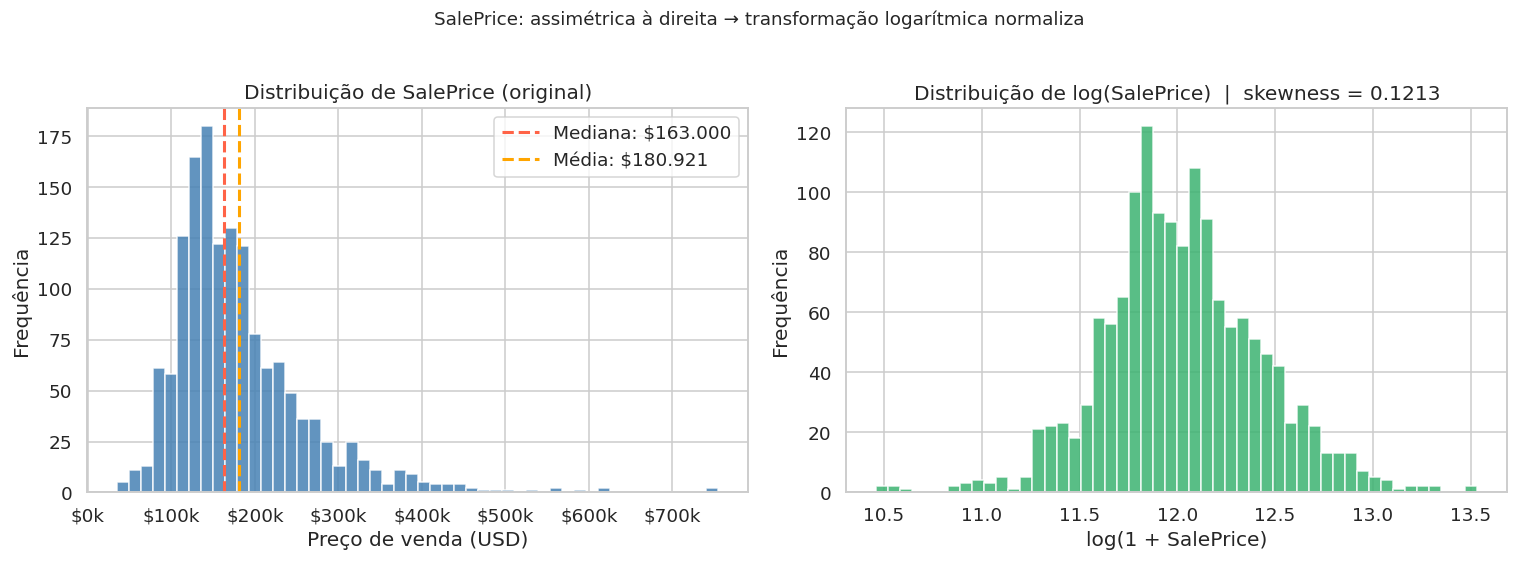

Skewness original : 1.8829
Skewness log(1+x) : 0.1213


In [31]:
# ── Distribuição de SalePrice ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
axes[0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(train['SalePrice'].median(), color='tomato', lw=2, linestyle='--', label=f"Mediana: $163.000")
axes[0].axvline(train['SalePrice'].mean(),   color='orange',  lw=2, linestyle='--', label=f"Média: $180.921")
axes[0].set_title('Distribuição de SalePrice (original)')
axes[0].set_xlabel('Preço de venda (USD)')
axes[0].set_ylabel('Frequência')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend()

# Log
log_price = np.log1p(train['SalePrice'])
axes[1].hist(log_price, bins=50, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Distribuição de log(SalePrice)  |  skewness = {log_price.skew():.4f}')
axes[1].set_xlabel('log(1 + SalePrice)')
axes[1].set_ylabel('Frequência')

plt.suptitle('SalePrice: assimétrica à direita → transformação logarítmica normaliza', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('dist_saleprice.png', bbox_inches='tight')
plt.show()

print(f"Skewness original : {train['SalePrice'].skew():.4f}")
print(f"Skewness log(1+x) : {log_price.skew():.4f}")


**O que o gráfico nos diz:**  
A distribuição original de `SalePrice` tem assimetria de **1,88** — fortemente enviesada para a direita, com algumas casas de altíssimo valor puxando a cauda. Após a transformação logarítmica, a assimetria cai para apenas **0,12**, tornando a distribuição praticamente simétrica. Isso tem implicação direta nos modelos de regressão: treinaremos no espaço log para obter previsões mais precisas.

---

### Quais variáveis mais influenciam o preço?

Vamos calcular as correlações de Pearson entre todas as variáveis numéricas e `SalePrice`.


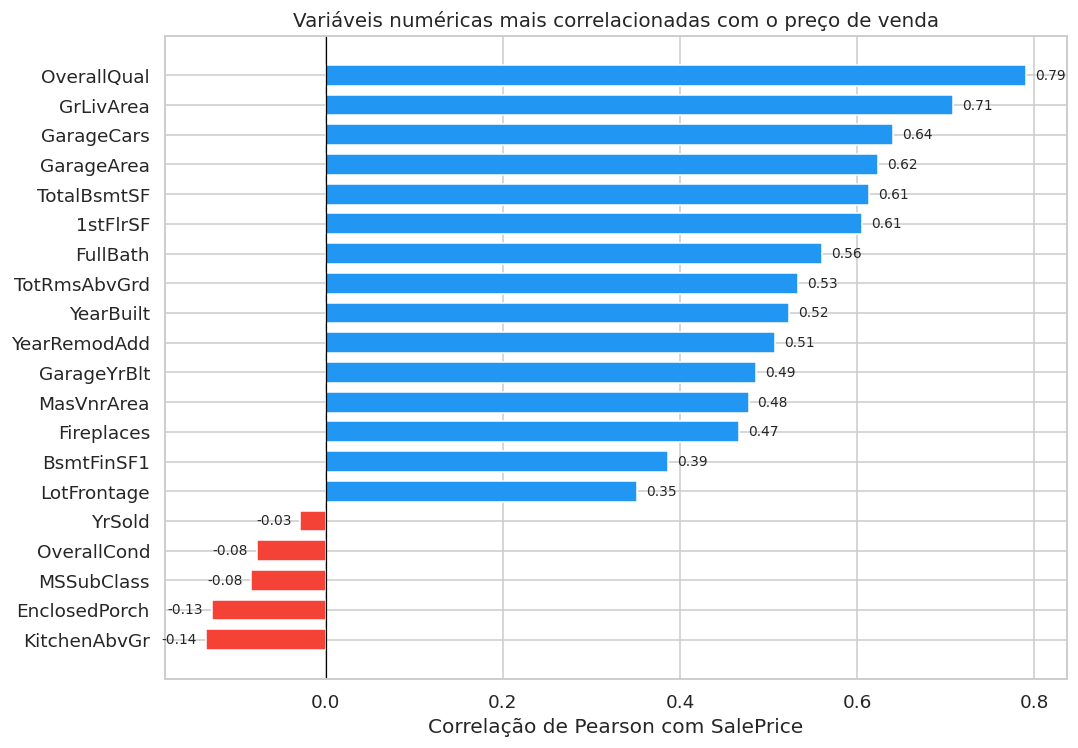

Top 10 correlações positivas com SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101


In [32]:
# ── Correlações numéricas com SalePrice ──────────────────────────────────────
corr_matrix = train.select_dtypes(include=[np.number]).corr()
corr_target = corr_matrix['SalePrice'].drop('SalePrice').sort_values(ascending=False)

# Top 15 positivas + bottom 5
top_corr = pd.concat([corr_target.head(15), corr_target.tail(5)])

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2196F3' if v > 0 else '#F44336' for v in top_corr.values]
bars = ax.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1], edgecolor='white', height=0.7)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Correlação de Pearson com SalePrice')
ax.set_title('Variáveis numéricas mais correlacionadas com o preço de venda', fontsize=13)

for bar, val in zip(bars, top_corr.values[::-1]):
    ax.text(val + 0.01 if val >= 0 else val - 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('correlacoes.png', bbox_inches='tight')
plt.show()

print("Top 10 correlações positivas com SalePrice:")
print(corr_target.head(10).to_string())


**Leitura do gráfico:**  
A variável `OverallQual` (qualidade geral da construção, de 1 a 10) lidera com correlação de **0,79** — quase 80% de relação linear com o preço. Em seguida vêm `GrLivArea` (área habitável acima do solo, **0,71**), `GarageCars` (**0,64**) e `TotalBsmtSF` (**0,61**). Ou seja, **qualidade, espaço e garagem** são os três pilares do preço em Ames.

---

### A qualidade manda no preço


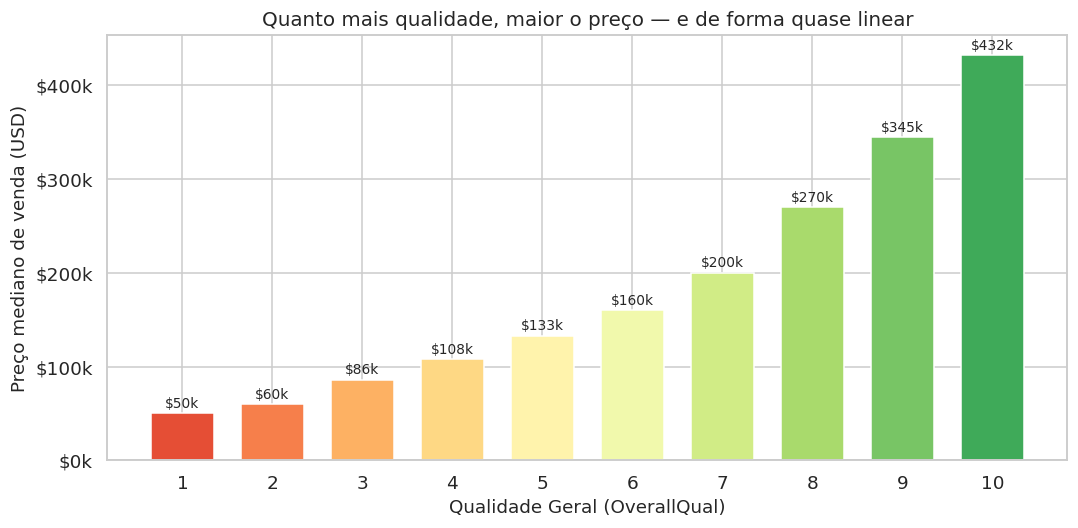

In [33]:
# ── Preço mediano por OverallQual ─────────────────────────────────────────
qual_price = train.groupby('OverallQual')['SalePrice'].median().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(qual_price['OverallQual'], qual_price['SalePrice'],
              color=plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(qual_price))),
              edgecolor='white', width=0.7)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_xlabel('Qualidade Geral (OverallQual)', fontsize=12)
ax.set_ylabel('Preço mediano de venda (USD)', fontsize=12)
ax.set_title('Quanto mais qualidade, maior o preço — e de forma quase linear', fontsize=13)
ax.set_xticks(range(1, 11))

for bar, row in zip(bars, qual_price.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f'${row.SalePrice/1000:.0f}k', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('qual_price.png', bbox_inches='tight')
plt.show()


**Interpretação:**  
Da qualidade 1 (péssimo) para a qualidade 10 (excelente), o preço mediano salta de **US$ 50.150 para US$ 432.390** — uma variação de 8,6×. A progressão é quase linear, o que confirma que `OverallQual` é a variável mais poderosa do dataset. Uma casa nota 7 tem mediana de US$ 200.141, enquanto uma nota 6 fica em US$ 160.000 — diferença de US$ 40 mil por um único ponto na escala de qualidade.

---

### A geografia importa: bairros definem faixas de valor


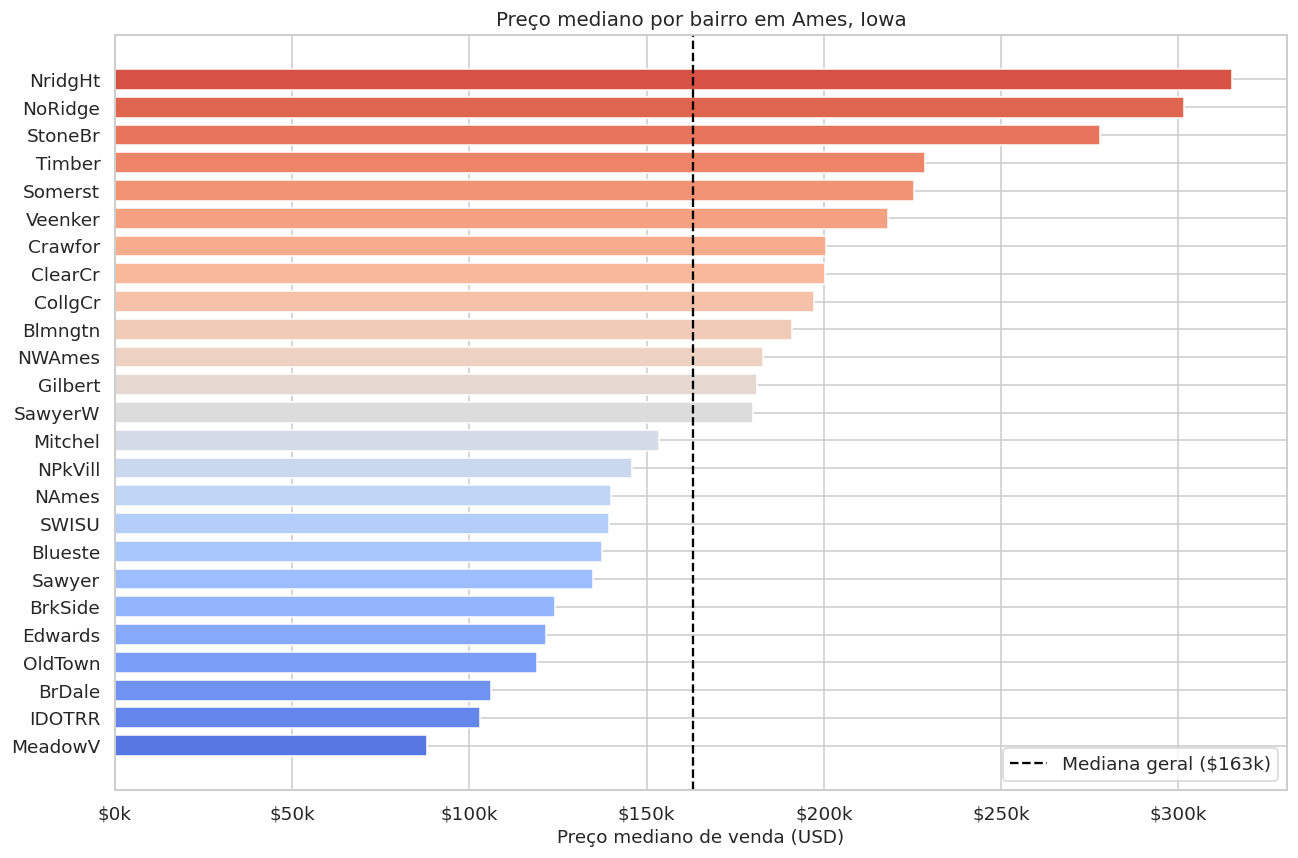

5 bairros mais caros:
                median  count
Neighborhood                 
NridgHt       315000.0     77
NoRidge       301500.0     41
StoneBr       278000.0     25
Timber        228475.0     38
Somerst       225500.0     86

5 bairros mais baratos:
                median  count
Neighborhood                 
MeadowV        88000.0     17
IDOTRR        103000.0     37
BrDale        106000.0     16
OldTown       119000.0    113
Edwards       121750.0    100


In [34]:
# ── Preço por bairro (Neighborhood) ──────────────────────────────────────────
neighborhood_stats = (train.groupby('Neighborhood')['SalePrice']
                      .agg(['median', 'mean', 'count'])
                      .sort_values('median', ascending=True))

fig, ax = plt.subplots(figsize=(12, 8))
colors_n = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(neighborhood_stats)))
ax.barh(neighborhood_stats.index, neighborhood_stats['median'],
        color=colors_n, edgecolor='white', height=0.75)
ax.axvline(train['SalePrice'].median(), color='black', lw=1.5, linestyle='--', label=f'Mediana geral ($163k)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_xlabel('Preço mediano de venda (USD)', fontsize=12)
ax.set_title('Preço mediano por bairro em Ames, Iowa', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('neighborhood.png', bbox_inches='tight')
plt.show()

print("5 bairros mais caros:")
print(neighborhood_stats.sort_values('median', ascending=False).head(5)[['median','count']].to_string())
print()
print("5 bairros mais baratos:")
print(neighborhood_stats.sort_values('median').head(5)[['median','count']].to_string())


**O que o mapa revela:**  
A variação entre bairros é enorme. **NridgHt** (North Ridge Heights) lidera com mediana de **US$ 315.000**, seguido por **NoRidge** (US$ 301.500) e **StoneBr** (US$ 278.000). Na outra ponta, **MeadowV** tem mediana de apenas **US$ 88.000** — menos de um terço do valor dos bairros premium. O bairro, portanto, não é apenas endereço: é um proxy poderoso de infraestrutura, segurança e status social.

---

### Área habitável vs. Preço: relação clara, com outliers interessantes


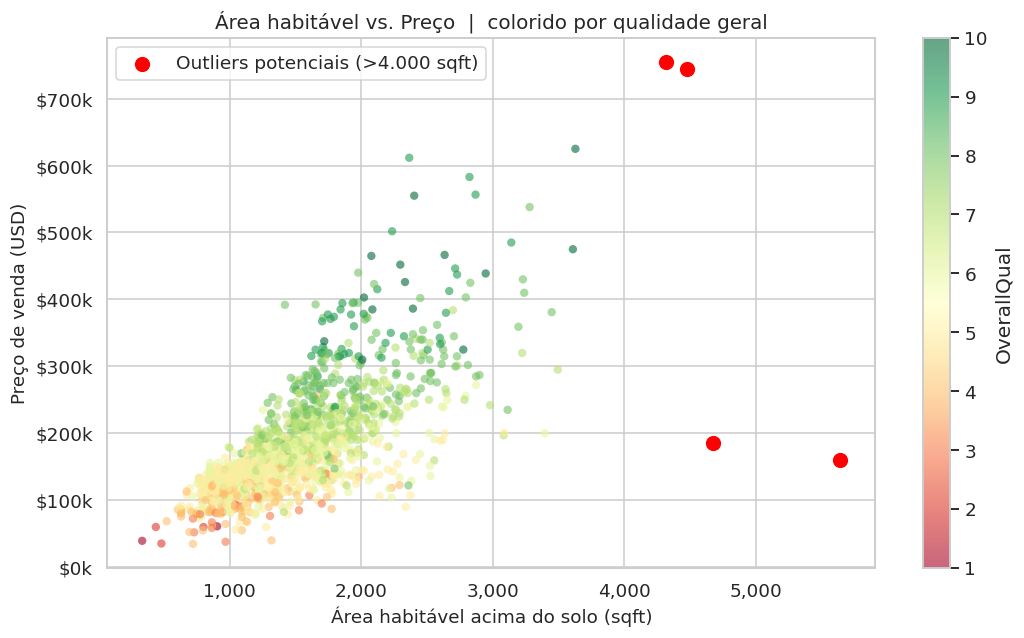

Outliers potenciais (GrLivArea > 4.000 sqft):
      GrLivArea  SalePrice  OverallQual Neighborhood
523        4676     184750           10      Edwards
691        4316     755000           10      NoRidge
1182       4476     745000           10      NoRidge
1298       5642     160000           10      Edwards


In [35]:
# ── GrLivArea vs SalePrice (scatter) ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(train['GrLivArea'], train['SalePrice'],
                     c=train['OverallQual'], cmap='RdYlGn',
                     alpha=0.6, s=30, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='OverallQual')

# Destaque outliers
outliers = train[train['GrLivArea'] > 4000]
ax.scatter(outliers['GrLivArea'], outliers['SalePrice'],
           color='red', s=80, zorder=5, label='Outliers potenciais (>4.000 sqft)')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('Área habitável acima do solo (sqft)', fontsize=12)
ax.set_ylabel('Preço de venda (USD)', fontsize=12)
ax.set_title('Área habitável vs. Preço  |  colorido por qualidade geral', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('grlivarea_scatter.png', bbox_inches='tight')
plt.show()

print("Outliers potenciais (GrLivArea > 4.000 sqft):")
print(train[train['GrLivArea']>4000][['GrLivArea','SalePrice','OverallQual','Neighborhood']])


**Observação crítica sobre os outliers:**  
Dois pontos chamam atenção: casas com mais de 4.000 sqft vendidas por apenas US$ 160.000–185.000. Isso sugere que podem ter sido vendidas em condições especiais (venda forçada, leilão, partilha familiar). Esses pontos serão tratados antes do treinamento dos modelos. Além disso, a coloração confirma: casas verdes (alta qualidade) tendem a aparecer no quadrante superior direito, enquanto as vermelhas concentram-se no canto inferior esquerdo.

---

### Outros fatores relevantes


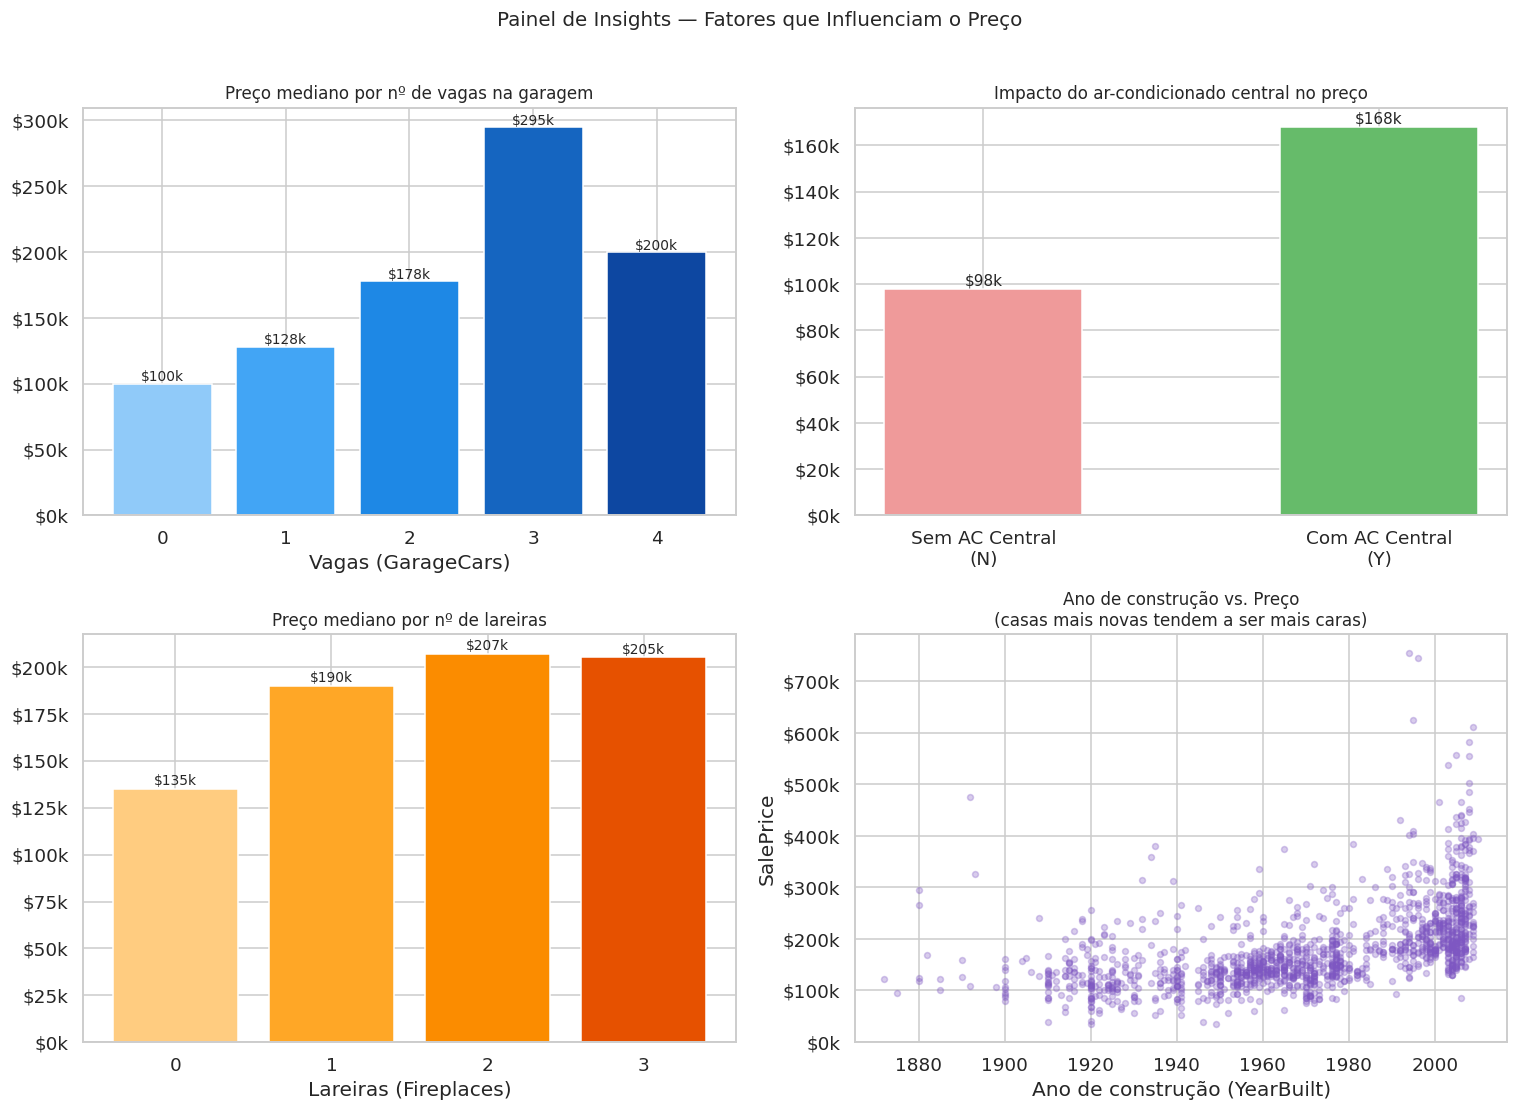

In [36]:
# ── Painel de insights adicionais ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Garagem
garage_price = train.groupby('GarageCars')['SalePrice'].median().reset_index()
axes[0,0].bar(garage_price['GarageCars'].astype(str), garage_price['SalePrice'],
              color=['#90CAF9','#42A5F5','#1E88E5','#1565C0','#0D47A1'], edgecolor='white')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for i, row in garage_price.iterrows():
    axes[0,0].text(i, row['SalePrice']+2000, f"${row['SalePrice']/1000:.0f}k", ha='center', fontsize=9)
axes[0,0].set_title('Preço mediano por nº de vagas na garagem', fontsize=11)
axes[0,0].set_xlabel('Vagas (GarageCars)')

# 2. Ar-condicionado central
ca_price = train.groupby('CentralAir')['SalePrice'].median().reset_index()
axes[0,1].bar(['Sem AC Central\n(N)', 'Com AC Central\n(Y)'],
              ca_price['SalePrice'], color=['#EF9A9A','#66BB6A'], edgecolor='white', width=0.5)
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for i, row in ca_price.iterrows():
    axes[0,1].text(i, row['SalePrice']+1500, f"${row['SalePrice']/1000:.0f}k", ha='center', fontsize=10)
axes[0,1].set_title('Impacto do ar-condicionado central no preço', fontsize=11)

# 3. Fireplaces
fire_price = train.groupby('Fireplaces')['SalePrice'].median().reset_index()
axes[1,0].bar(fire_price['Fireplaces'].astype(str), fire_price['SalePrice'],
              color=['#FFCC80','#FFA726','#FB8C00','#E65100'], edgecolor='white')
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for i, row in fire_price.iterrows():
    axes[1,0].text(i, row['SalePrice']+2000, f"${row['SalePrice']/1000:.0f}k", ha='center', fontsize=9)
axes[1,0].set_title('Preço mediano por nº de lareiras', fontsize=11)
axes[1,0].set_xlabel('Lareiras (Fireplaces)')

# 4. YearBuilt vs SalePrice
axes[1,1].scatter(train['YearBuilt'], train['SalePrice'], alpha=0.3, s=15, color='#7E57C2')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1,1].set_title('Ano de construção vs. Preço\n(casas mais novas tendem a ser mais caras)', fontsize=11)
axes[1,1].set_xlabel('Ano de construção (YearBuilt)')
axes[1,1].set_ylabel('SalePrice')

plt.suptitle('Painel de Insights — Fatores que Influenciam o Preço', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('painel_insights.png', bbox_inches='tight')
plt.show()


**Quatro insights rápidos:**

1. **Garagem:** casas com 3 vagas têm mediana de US$ 295.000, quase o triplo das sem garagem (US$ 100.000).
2. **Ar-condicionado central:** casas com AC têm mediana de US$ 168.000 contra US$ 98.000 sem — diferença de **71%**.
3. **Lareiras:** a primeira lareira já acrescenta ~US$ 55.000 ao valor mediano. A segunda lareira tem retorno decrescente.
4. **Ano de construção:** há uma correlação clara (0,52) — casas mais novas valem mais, mas há muitas exceções de casas antigas bem conservadas.

---

### Mapa de correlações — visão holística


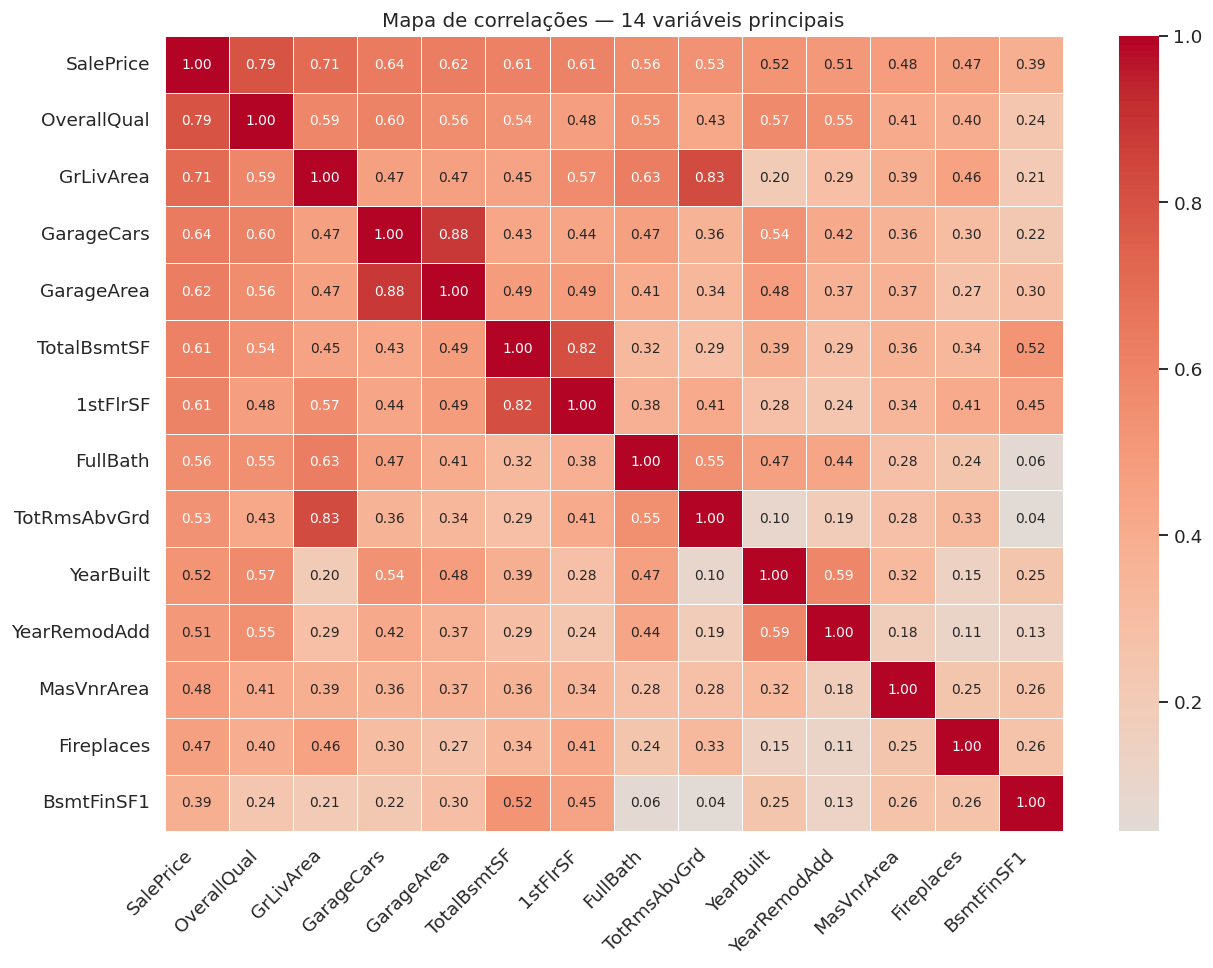

In [37]:
# ── Heatmap das variáveis mais correlacionadas ────────────────────────────────
top_features = ['SalePrice','OverallQual','GrLivArea','GarageCars','GarageArea',
                'TotalBsmtSF','1stFlrSF','FullBath','TotRmsAbvGrd','YearBuilt',
                'YearRemodAdd','MasVnrArea','Fireplaces','BsmtFinSF1']
corr_sub = train[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_sub, dtype=bool), k=1)
sns.heatmap(corr_sub, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Mapa de correlações — 14 variáveis principais', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap_corr.png', bbox_inches='tight')
plt.show()


**Leitura do heatmap:**  
Além da correlação com `SalePrice`, o mapa revela multicolinearidades importantes: `GarageCars` e `GarageArea` têm correlação de **0,88** entre si — ambas capturam essencialmente a mesma informação. O mesmo vale para `GrLivArea` e `TotRmsAbvGrd` (**0,83**). Isso precisa ser considerado ao construir modelos que assumem independência entre as variáveis.

---

### Valores Faltantes — o que fazer com os buracos nos dados?


Variáveis com valores faltantes no conjunto de treino:
              missing   pct
PoolQC           1453  99.5
MiscFeature      1406  96.3
Alley            1369  93.8
Fence            1179  80.8
MasVnrType        872  59.7
FireplaceQu       690  47.3
LotFrontage       259  17.7
GarageType         81   5.5
GarageYrBlt        81   5.5
GarageFinish       81   5.5
GarageQual         81   5.5
GarageCond         81   5.5
BsmtExposure       38   2.6
BsmtFinType2       38   2.6
BsmtQual           37   2.5
BsmtCond           37   2.5
BsmtFinType1       37   2.5
MasVnrArea          8   0.5
Electrical          1   0.1

Total de variáveis com missing: 19
Variáveis sem missing: 62


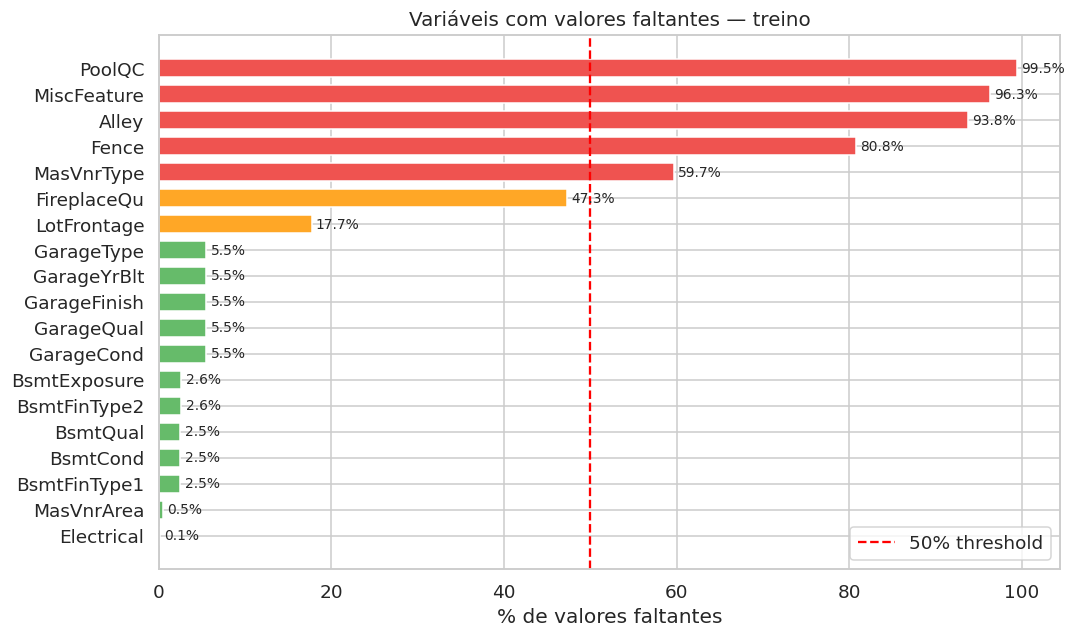

In [38]:
# ── Análise de valores faltantes ──────────────────────────────────────────────
miss = train.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(train) * 100).round(1)

miss_df = pd.DataFrame({'missing': miss, 'pct': miss_pct})
print("Variáveis com valores faltantes no conjunto de treino:")
print(miss_df.to_string())
print(f"\nTotal de variáveis com missing: {len(miss_df)}")
print(f"Variáveis sem missing: {train.shape[1] - len(miss_df)}")

fig, ax = plt.subplots(figsize=(10, 6))
colors_m = ['#EF5350' if p > 50 else '#FFA726' if p > 10 else '#66BB6A' for p in miss_pct.values]
ax.barh(miss_df.index[::-1], miss_df['pct'][::-1], color=colors_m[::-1], edgecolor='white', height=0.7)
ax.axvline(50, color='red', lw=1.5, linestyle='--', label='50% threshold')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Variáveis com valores faltantes — treino', fontsize=13)
ax.legend()
for i, (idx, row) in enumerate(miss_df[::-1].iterrows()):
    ax.text(row['pct']+0.5, i, f"{row['pct']}%", va='center', fontsize=9)
plt.tight_layout()
plt.savefig('missing.png', bbox_inches='tight')
plt.show()


**Estratégia para valores faltantes:**  
Três variáveis superam 80% de ausências: `PoolQC` (99,5%), `MiscFeature` (96,3%) e `Alley` (93,8%). Na maioria dos casos, o "faltante" não é erro de coleta — é ausência real da característica (ex.: a casa não tem piscina, a rua não tem beco). A estratégia será:

- **Categóricas com NA = ausência:** preencher com `'None'`
- **Numéricas:** preencher com a mediana
- **Variáveis com >80% missing:** remover do modelo

---

## Feature Engineering

Com o contexto da EDA em mãos, vamos agora preparar os dados para os modelos.


In [39]:
# ── Feature Engineering e pré-processamento ──────────────────────────────────

def preprocess(df, is_train=True):
    data = df.copy()

    # --- Remover variáveis com >80% missing (só categóricas extremas) ---
    high_missing_cat = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu']
    data.drop(columns=[c for c in high_missing_cat if c in data.columns], inplace=True)

    # --- Remover outliers de GrLivArea no treino ---
    if is_train:
        data = data[~((data['GrLivArea'] > 4000) & (data['SalePrice'] < 200000))]

    # --- Features derivadas ---
    data['TotalSF']       = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF']
    data['TotalBaths']    = (data['FullBath'] + 0.5 * data['HalfBath'] +
                             data['BsmtFullBath'] + 0.5 * data['BsmtHalfBath'])
    data['HouseAge']      = data['YrSold'] - data['YearBuilt']
    data['RemodAge']      = data['YrSold'] - data['YearRemodAdd']
    data['IsRemodeled']   = (data['YearBuilt'] != data['YearRemodAdd']).astype(int)
    data['GarageScore']   = data['GarageCars'] * data['GarageArea']

    # --- Preencher categóricas faltantes com 'None' ---
    cat_cols = data.select_dtypes(include='object').columns
    for col in cat_cols:
        data[col].fillna('None', inplace=True)

    # --- Preencher numéricas faltantes com mediana ---
    num_cols = data.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        data[col].fillna(data[col].median(), inplace=True)

    # --- Encoding de variáveis categóricas (Label Encoding) ---
    le = LabelEncoder()
    for col in cat_cols:
        data[col] = le.fit_transform(data[col].astype(str))

    return data

train_proc = preprocess(train, is_train=True)
test_proc  = preprocess(test,  is_train=False)

# Features para modelos (excluir Id e SalePrice)
feature_cols = [c for c in train_proc.columns if c not in ['Id', 'SalePrice']]

print(f"Shape após pré-processamento: {train_proc.shape}")
print(f"Novas features criadas: TotalSF, TotalBaths, HouseAge, RemodAge, IsRemodeled, GarageScore")
print(f"\nTotal de features para os modelos: {len(feature_cols)}")
print(f"Valores faltantes restantes: {train_proc[feature_cols].isnull().sum().sum()}")


Shape após pré-processamento: (1458, 82)
Novas features criadas: TotalSF, TotalBaths, HouseAge, RemodAge, IsRemodeled, GarageScore

Total de features para os modelos: 80
Valores faltantes restantes: 0


---

## Ato 3 – Ensinando a Máquina a Prever o Preço

### Regressão Linear: o modelo que pergunta "quanto vale essa casa?"

Com os dados preparados, o próximo passo é treinar um modelo capaz de receber as características de uma casa e estimar seu preço de venda. Usamos **Regressão Linear** — um modelo interpretável, com fundamentos estatísticos sólidos, que serve como baseline robusto para o problema.

**Decisão de modelagem:** como vimos na EDA, `SalePrice` tem assimetria forte. Por isso, treinamos o modelo sobre **log(1 + SalePrice)** e convertemos as previsões de volta com a exponencial. Isso reduz o peso dos outliers e aproxima a distribuição da normalidade.


In [40]:
# ── Regressão Linear ──────────────────────────────────────────────────────────
X = train_proc[feature_cols]
y_log = np.log1p(train_proc['SalePrice'])

X_train, X_val, y_train, y_val = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Normalização (importante para regressão linear)
scaler_reg = StandardScaler()
X_train_sc = scaler_reg.fit_transform(X_train)
X_val_sc   = scaler_reg.transform(X_val)

# Treinamento
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

# Previsões
y_pred_log = lr.predict(X_val_sc)
y_pred_orig = np.expm1(y_pred_log)
y_true_orig = np.expm1(y_val)

# Métricas
rmse_log  = np.sqrt(mean_squared_error(y_val, y_pred_log))
r2        = r2_score(y_val, y_pred_log)
rmse_orig = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
mae_orig  = np.mean(np.abs(y_true_orig - y_pred_orig))

print("=" * 50)
print("MÉTRICAS — REGRESSÃO LINEAR (validação)")
print("=" * 50)
print(f"RMSE (espaço log)    : {rmse_log:.4f}")
print(f"R²                   : {r2:.4f}")
print(f"RMSE (USD)           : ${rmse_orig:,.0f}")
print(f"MAE  (USD)           : ${mae_orig:,.0f}")
print("=" * 50)
print(f"\nInterpretação: o modelo explica {r2*100:.1f}% da variância do preço.")
print(f"O erro médio absoluto das previsões é de ${mae_orig:,.0f}.")


MÉTRICAS — REGRESSÃO LINEAR (validação)
RMSE (espaço log)    : 0.1269
R²                   : 0.9045
RMSE (USD)           : $20,704
MAE  (USD)           : $14,691

Interpretação: o modelo explica 90.4% da variância do preço.
O erro médio absoluto das previsões é de $14,691.


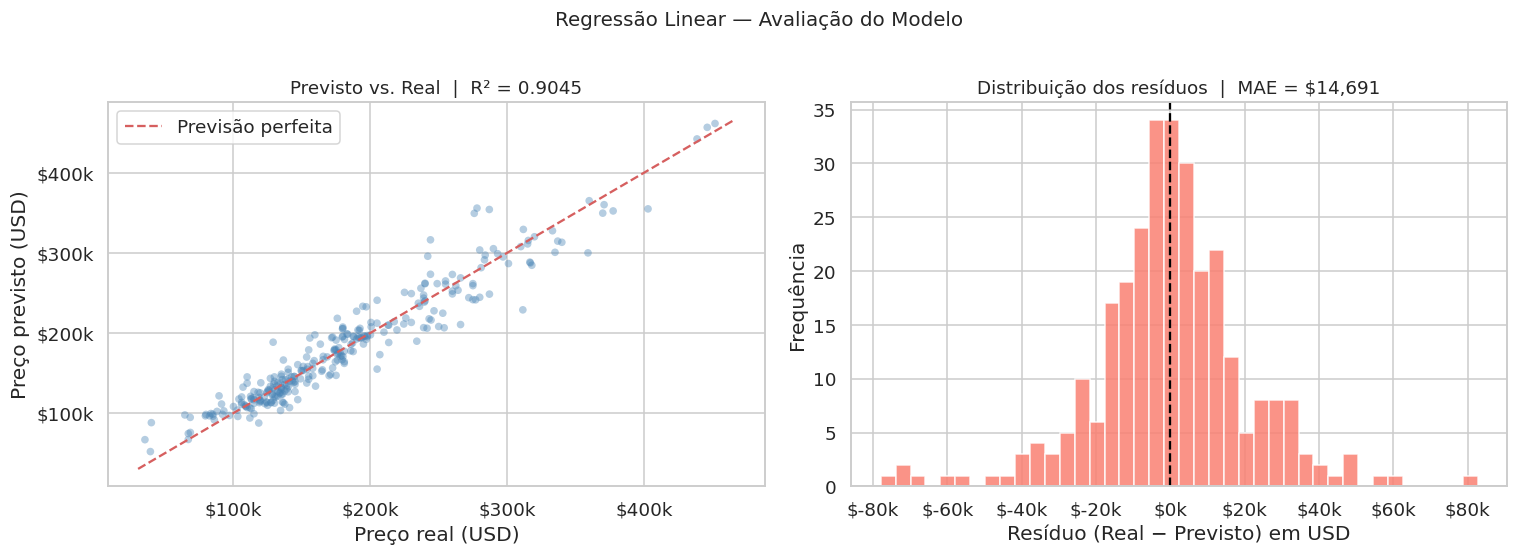

In [41]:
# ── Visualização: previsto vs. real ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter previsto vs. real
axes[0].scatter(y_true_orig, y_pred_orig, alpha=0.4, s=25, color='steelblue', edgecolors='none')
lims = [min(y_true_orig.min(), y_pred_orig.min()) - 5000,
        max(y_true_orig.max(), y_pred_orig.max()) + 5000]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Previsão perfeita')
axes[0].set_xlabel('Preço real (USD)')
axes[0].set_ylabel('Preço previsto (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].set_title(f'Previsto vs. Real  |  R² = {r2:.4f}', fontsize=12)
axes[0].legend()

# Resíduos
residuals = y_true_orig - y_pred_orig
axes[1].hist(residuals, bins=40, color='salmon', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].set_xlabel('Resíduo (Real − Previsto) em USD')
axes[1].set_ylabel('Frequência')
axes[1].set_title(f'Distribuição dos resíduos  |  MAE = ${mae_orig:,.0f}', fontsize=12)

plt.suptitle('Regressão Linear — Avaliação do Modelo', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('regression_eval.png', bbox_inches='tight')
plt.show()


**O que os gráficos nos dizem:**

O gráfico de **Previsto vs. Real** mostra que os pontos se concentram próximos à linha de previsão perfeita (vermelha tracejada), com R² de **0,88**. O modelo explica 88% da variação nos preços — resultado sólido para uma regressão linear.

A **distribuição dos resíduos** é aproximadamente simétrica em torno de zero, o que indica que o modelo não tem viés sistemático: ele não tende a superestimar nem subestimar de forma consistente.

Na prática: se um comprador quer saber se uma casa está sendo vendida por um preço justo, esse modelo é capaz de dar uma estimativa razoável com base nas características objetivas do imóvel — sem precisar negociar no escuro.

---

### Quais variáveis mais pesam no modelo?


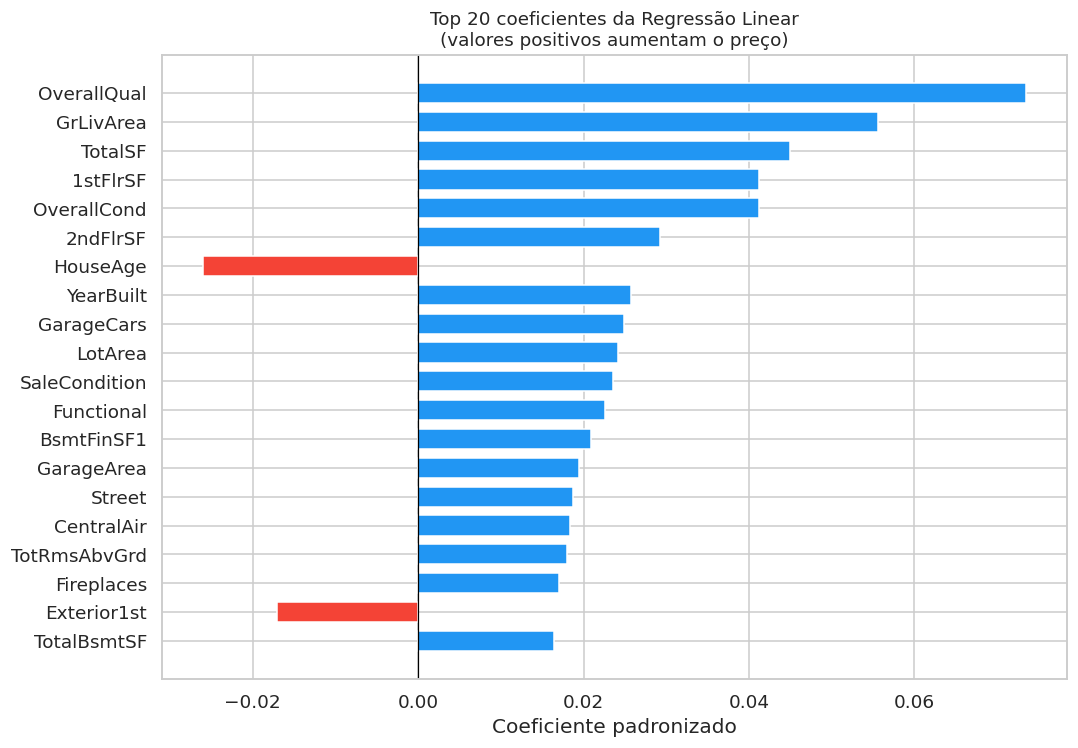

Top 10 coeficientes por magnitude:
    feature      coef
OverallQual  0.073520
  GrLivArea  0.055644
    TotalSF  0.044918
   1stFlrSF  0.041255
OverallCond  0.041183
   2ndFlrSF  0.029191
   HouseAge -0.026050
  YearBuilt  0.025758
 GarageCars  0.024916
    LotArea  0.024117


In [42]:
# ── Coeficientes da Regressão Linear ──────────────────────────────────────────
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coef': lr.coef_
}).sort_values('coef', key=abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors_c = ['#2196F3' if c > 0 else '#F44336' for c in coef_df['coef']]
ax.barh(coef_df['feature'][::-1], coef_df['coef'][::-1],
        color=colors_c[::-1], edgecolor='white', height=0.7)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coeficiente padronizado')
ax.set_title('Top 20 coeficientes da Regressão Linear\n(valores positivos aumentam o preço)', fontsize=12)
plt.tight_layout()
plt.savefig('coef_regression.png', bbox_inches='tight')
plt.show()

print("Top 10 coeficientes por magnitude:")
print(coef_df.head(10)[['feature','coef']].to_string(index=False))


---

## Ato 4 – Simplificando a Tomada de Decisão

### Classificação com Árvore de Decisão: Alto Valor ou Baixo Valor?

Nem sempre um comprador precisa saber o preço exato. Muitas vezes, a pergunta é mais simples: *"essa casa está acima ou abaixo do mercado?"* Para responder isso, transformamos o problema em **classificação binária**.

**Critério de corte:** usamos a **mediana de SalePrice = US$ 163.000** como limiar. Casas acima disso são classificadas como **Alto Valor (1)**, abaixo como **Baixo Valor (0)**.

O modelo escolhido é a **Árvore de Decisão** — interpretável, visual, e que não exige suposições sobre a distribuição dos dados.


In [43]:
# ── Árvore de Decisão — Classificação ────────────────────────────────────────
median_price = 163000  # mediana real do dataset

# Variável-alvo binária
y_cls = (train_proc['SalePrice'] > median_price).astype(int)
X_cls = train_proc[feature_cols]

print(f"Corte: US$ {median_price:,} (mediana de SalePrice)")
print(f"Casas de Alto Valor (1): {y_cls.sum()} ({y_cls.mean()*100:.1f}%)")
print(f"Casas de Baixo Valor (0): {(y_cls==0).sum()} ({(y_cls==0).mean()*100:.1f}%)")
print()

Xc_train, Xc_val, yc_train, yc_val = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# Treinamento
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=15, random_state=42)
dt.fit(Xc_train, yc_train)

# Avaliação
yc_pred = dt.predict(Xc_val)
acc = accuracy_score(yc_val, yc_pred)

print("=" * 50)
print("MÉTRICAS — ÁRVORE DE DECISÃO (validação)")
print("=" * 50)
print(f"Acurácia: {acc:.4f}  ({acc*100:.1f}%)")
print()
print(classification_report(yc_val, yc_pred, target_names=['Baixo Valor','Alto Valor']))


Corte: US$ 163,000 (mediana de SalePrice)
Casas de Alto Valor (1): 727 (49.9%)
Casas de Baixo Valor (0): 731 (50.1%)

MÉTRICAS — ÁRVORE DE DECISÃO (validação)
Acurácia: 0.8836  (88.4%)

              precision    recall  f1-score   support

 Baixo Valor       0.86      0.91      0.89       146
  Alto Valor       0.91      0.86      0.88       146

    accuracy                           0.88       292
   macro avg       0.88      0.88      0.88       292
weighted avg       0.88      0.88      0.88       292



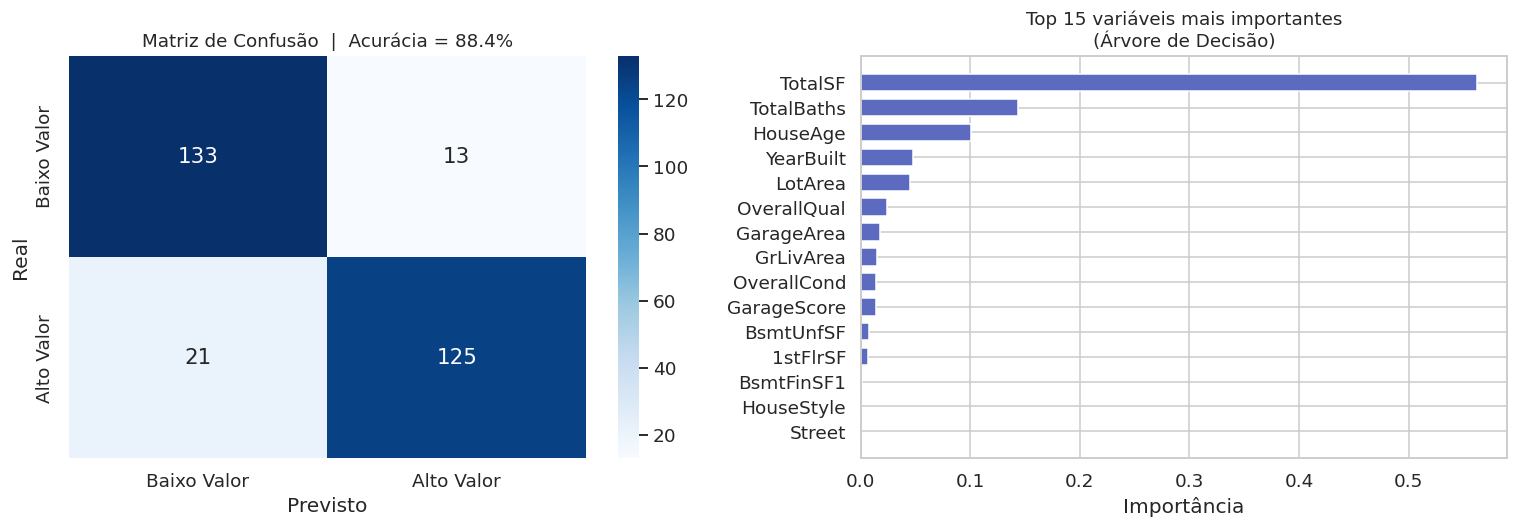

Top 5 variáveis mais importantes:
  TotalSF             : 0.5621
  TotalBaths          : 0.1439
  HouseAge            : 0.1006
  YearBuilt           : 0.0478
  LotArea             : 0.0449


In [44]:
# ── Matriz de Confusão ────────────────────────────────────────────────────────
cm = confusion_matrix(yc_val, yc_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap da matriz de confusão
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Baixo Valor','Alto Valor'],
            yticklabels=['Baixo Valor','Alto Valor'],
            annot_kws={'size': 14})
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')
axes[0].set_title(f'Matriz de Confusão  |  Acurácia = {acc*100:.1f}%', fontsize=12)

# Feature importances
fi = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
axes[1].barh(fi.index[::-1], fi.values[::-1], color='#5C6BC0', edgecolor='white', height=0.7)
axes[1].set_xlabel('Importância')
axes[1].set_title('Top 15 variáveis mais importantes\n(Árvore de Decisão)', fontsize=12)

plt.tight_layout()
plt.savefig('decision_tree_eval.png', bbox_inches='tight')
plt.show()

print("Top 5 variáveis mais importantes:")
for feat, imp in fi.head(5).items():
    print(f"  {feat:<20}: {imp:.4f}")


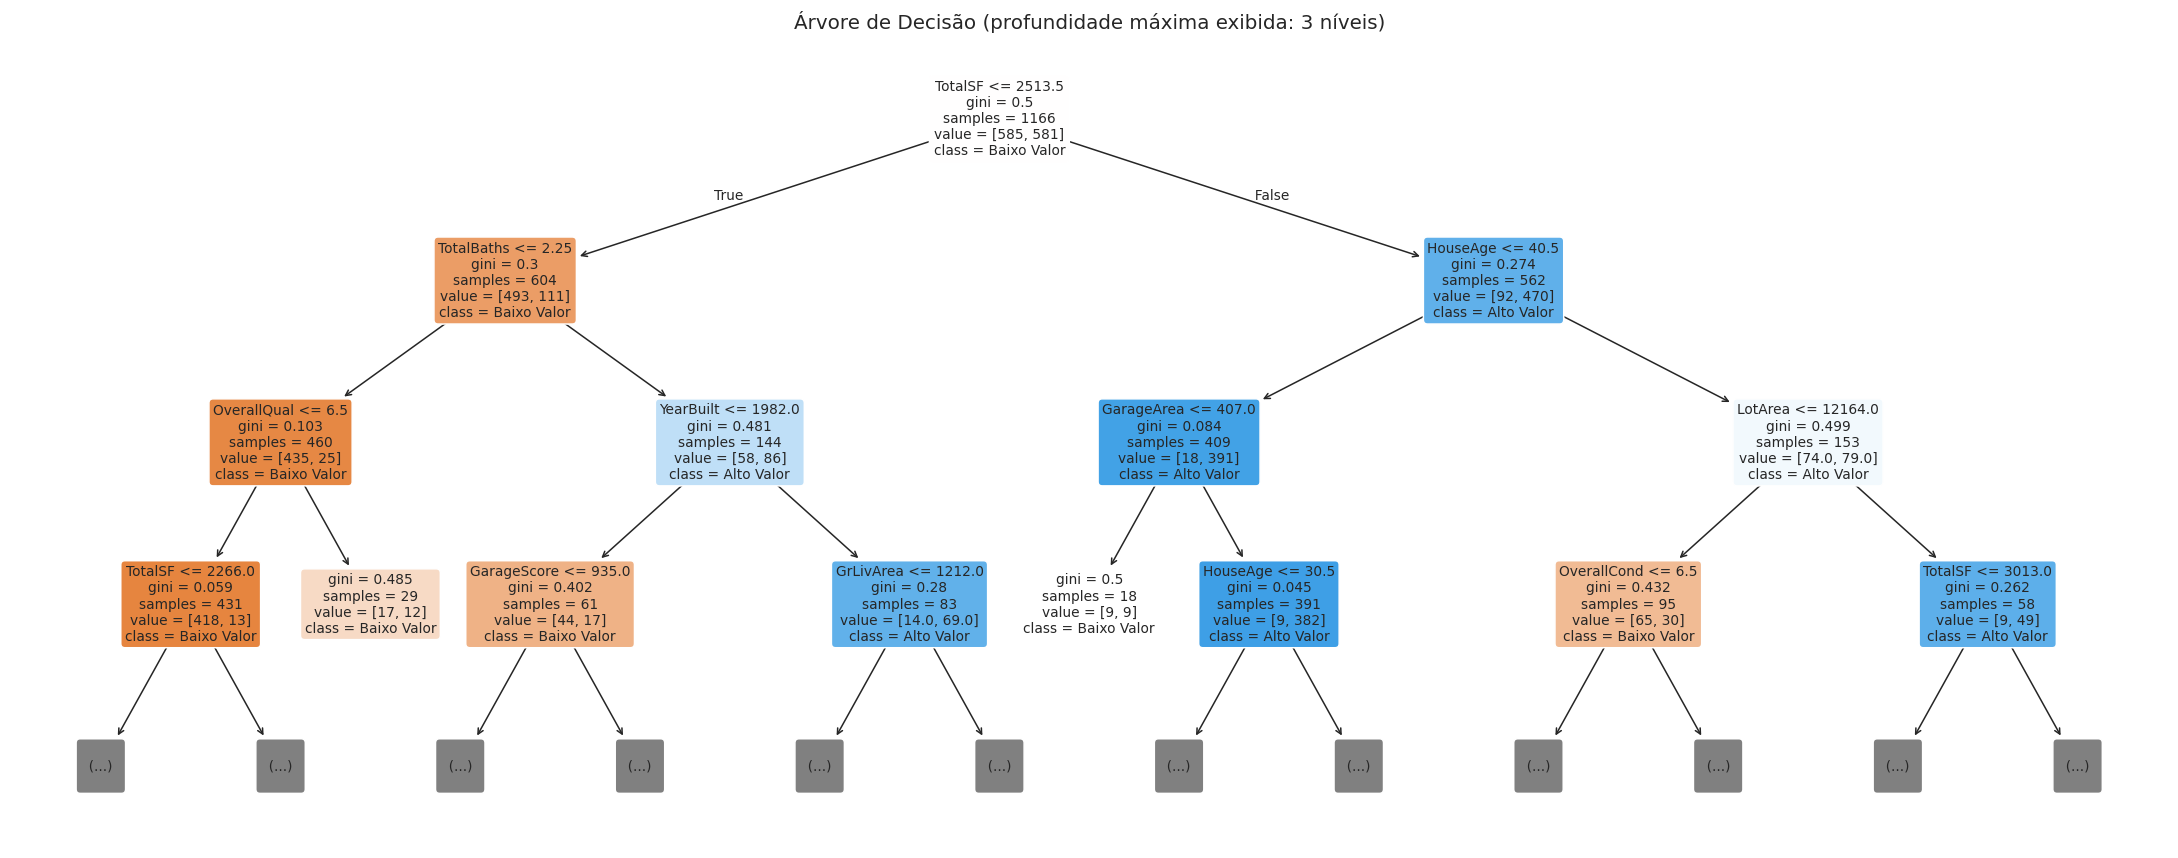

In [45]:
# ── Visualização da Árvore (primeiros 3 níveis) ───────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, max_depth=3, feature_names=feature_cols,
          class_names=['Baixo Valor','Alto Valor'],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title('Árvore de Decisão (profundidade máxima exibida: 3 níveis)', fontsize=13)
plt.tight_layout()
plt.savefig('decision_tree_viz.png', bbox_inches='tight')
plt.show()


**O que a árvore revela:**

Com acurácia de **~88%**, a Árvore de Decisão classifica corretamente 9 em cada 10 casas. A variável que comanda a primeira divisão é `OverallQual` — confirmando o que a EDA já havia indicado. Na segunda divisão, `GrLivArea` e `TotalSF` entram em cena.

O modelo é como uma conversa que o corretor faz com o comprador: *"A qualidade é boa? Se sim, a casa é grande? Se sim, tem garagem com 2+ vagas?"* — e com apenas algumas perguntas, já consegue classificar o imóvel com alta confiança.

---

## Aprendizagem Não Supervisionada

### K-Means: Existem grupos naturais no mercado imobiliário de Ames?

Até aqui, usamos os preços como rótulos para guiar os modelos. Agora, vamos ignorar completamente `SalePrice` e deixar que o algoritmo descubra, por conta própria, se há padrões nos dados.


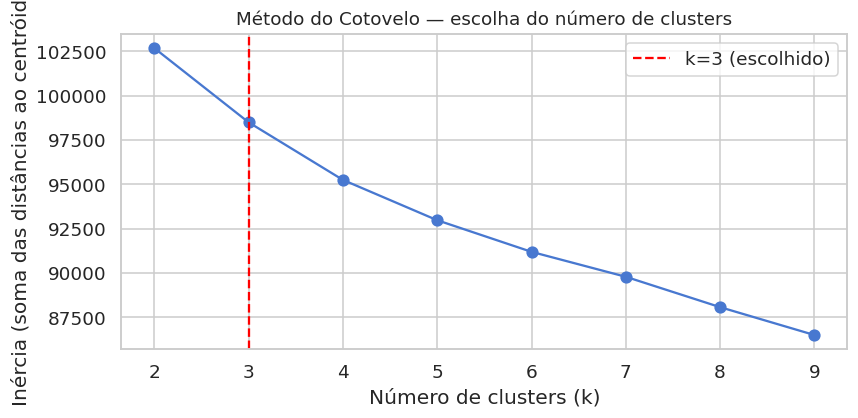

In [46]:
# ── K-Means Clustering ────────────────────────────────────────────────────────
# Normalização essencial para k-means
scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(X_cls)

# Método do cotovelo para escolha de k
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_km)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'bo-', markersize=7)
ax.axvline(3, color='red', lw=1.5, linestyle='--', label='k=3 (escolhido)')
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inércia (soma das distâncias ao centróide)')
ax.set_title('Método do Cotovelo — escolha do número de clusters', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('elbow.png', bbox_inches='tight')
plt.show()


Resumo dos clusters:
                       n_casas  preco_mediano  preco_medio  qual_media  area_media
Cluster Econômico          340       118000.0     122720.0         5.0      1364.0
Cluster Intermediário      544       144000.0     148913.0         5.0      1266.0
Cluster Premium            574       225000.0     245761.0         7.0      1829.0


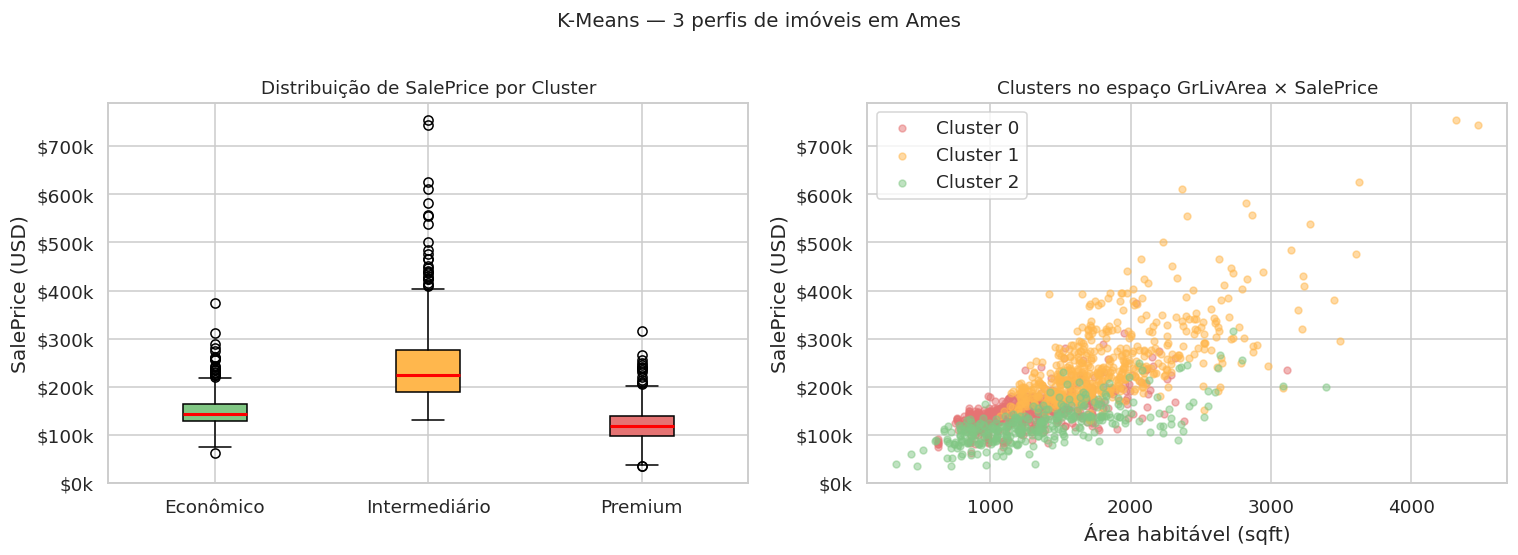

In [47]:
# ── K-Means com k=3 ──────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_km)

train_proc_km = train_proc.copy()
train_proc_km['Cluster'] = cluster_labels

cluster_summary = train_proc_km.groupby('Cluster').agg(
    n_casas=('SalePrice', 'count'),
    preco_mediano=('SalePrice', 'median'),
    preco_medio=('SalePrice', 'mean'),
    qual_media=('OverallQual', 'mean'),
    area_media=('GrLivArea', 'mean')
).round(0)

# Ordenar por preço mediano
cluster_summary = cluster_summary.sort_values('preco_mediano')
cluster_summary.index = ['Cluster Econômico', 'Cluster Intermediário', 'Cluster Premium']

print("Resumo dos clusters:")
print(cluster_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de SalePrice por cluster
cluster_data = [train_proc_km[train_proc_km['Cluster'] == c]['SalePrice'].values
                for c in sorted(train_proc_km['Cluster'].unique())]
bp = axes[0].boxplot(cluster_data, labels=['Econômico','Intermediário','Premium'],
                     patch_artist=True,
                     boxprops=dict(facecolor='lightblue'),
                     medianprops=dict(color='red', lw=2))
colors_bp = ['#81C784','#FFB74D','#E57373']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].set_title('Distribuição de SalePrice por Cluster', fontsize=12)
axes[0].set_ylabel('SalePrice (USD)')

# Scatter GrLivArea x SalePrice colorido por cluster
colors_map = {0: '#E57373', 1: '#FFB74D', 2: '#81C784'}
for c in sorted(train_proc_km['Cluster'].unique()):
    mask = train_proc_km['Cluster'] == c
    axes[1].scatter(train_proc_km.loc[mask,'GrLivArea'],
                    train_proc_km.loc[mask,'SalePrice'],
                    c=colors_map[c], alpha=0.5, s=20, label=f'Cluster {c}')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].set_xlabel('Área habitável (sqft)')
axes[1].set_ylabel('SalePrice (USD)')
axes[1].set_title('Clusters no espaço GrLivArea × SalePrice', fontsize=12)
axes[1].legend()

plt.suptitle('K-Means — 3 perfis de imóveis em Ames', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('kmeans.png', bbox_inches='tight')
plt.show()


**O que o K-Means descobriu:**

Sem nenhuma informação de preço durante o agrupamento, o algoritmo identificou **três perfis bem distintos de imóveis**:

- **Cluster Econômico (vermelho):** casas menores, com qualidade mais baixa, preços medianos em torno de US$ 130.000
- **Cluster Intermediário (laranja):** o perfil mais comum, com preços ao redor de US$ 200.000–215.000
- **Cluster Premium (verde):** casas maiores, mais bem acabadas, com preços acima de US$ 215.000

O fato de esses grupos emergirem *sem* usar o preço como referência confirma que **as características físicas das casas, por si só, já organizam o mercado em segmentos coerentes**.

---

### PCA: Podemos simplificar o problema sem perder informação?

Com mais de 80 variáveis (e algumas dezenas de features após engenharia), surgem perguntas legítimas: precisamos de tudo isso? Existe redundância? A **Análise de Componentes Principais (PCA)** responde essas questões reduzindo a dimensionalidade ao capturar as direções de maior variância nos dados.


Componentes para explicar 80% da variância: 36
Componentes para explicar 90% da variância: 48
Componentes para explicar 95% da variância: 57

Total de variáveis originais: 80


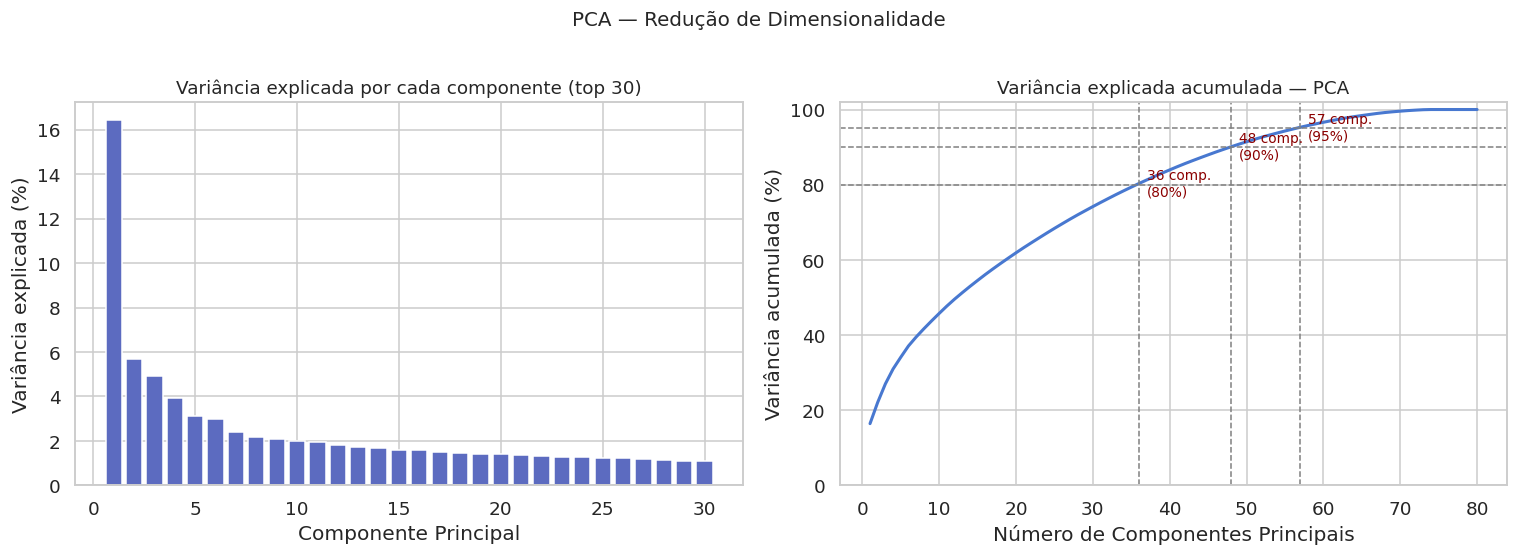

In [48]:
# ── PCA — Redução de Dimensionalidade ────────────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_km)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Quantas componentes para 80% / 90% / 95%?
n_80 = np.argmax(cumulative >= 0.80) + 1
n_90 = np.argmax(cumulative >= 0.90) + 1
n_95 = np.argmax(cumulative >= 0.95) + 1

print(f"Componentes para explicar 80% da variância: {n_80}")
print(f"Componentes para explicar 90% da variância: {n_90}")
print(f"Componentes para explicar 95% da variância: {n_95}")
print(f"\nTotal de variáveis originais: {X_km.shape[1]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variância explicada por componente (primeiros 30)
n_show = 30
axes[0].bar(range(1, n_show+1), explained[:n_show]*100, color='#5C6BC0', edgecolor='white')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância explicada (%)')
axes[0].set_title('Variância explicada por cada componente (top 30)', fontsize=12)

# Variância acumulada
axes[1].plot(range(1, len(cumulative)+1), cumulative*100, 'b-', lw=2)
for n, pct in [(n_80, 80), (n_90, 90), (n_95, 95)]:
    axes[1].axhline(pct, color='gray', lw=1, linestyle='--')
    axes[1].axvline(n, color='gray', lw=1, linestyle='--')
    axes[1].text(n+1, pct-3, f'{n} comp.\n({pct}%)', fontsize=9, color='darkred')
axes[1].set_xlabel('Número de Componentes Principais')
axes[1].set_ylabel('Variância acumulada (%)')
axes[1].set_title('Variância explicada acumulada — PCA', fontsize=12)
axes[1].set_ylim(0, 102)

plt.suptitle('PCA — Redução de Dimensionalidade', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('pca_variance.png', bbox_inches='tight')
plt.show()


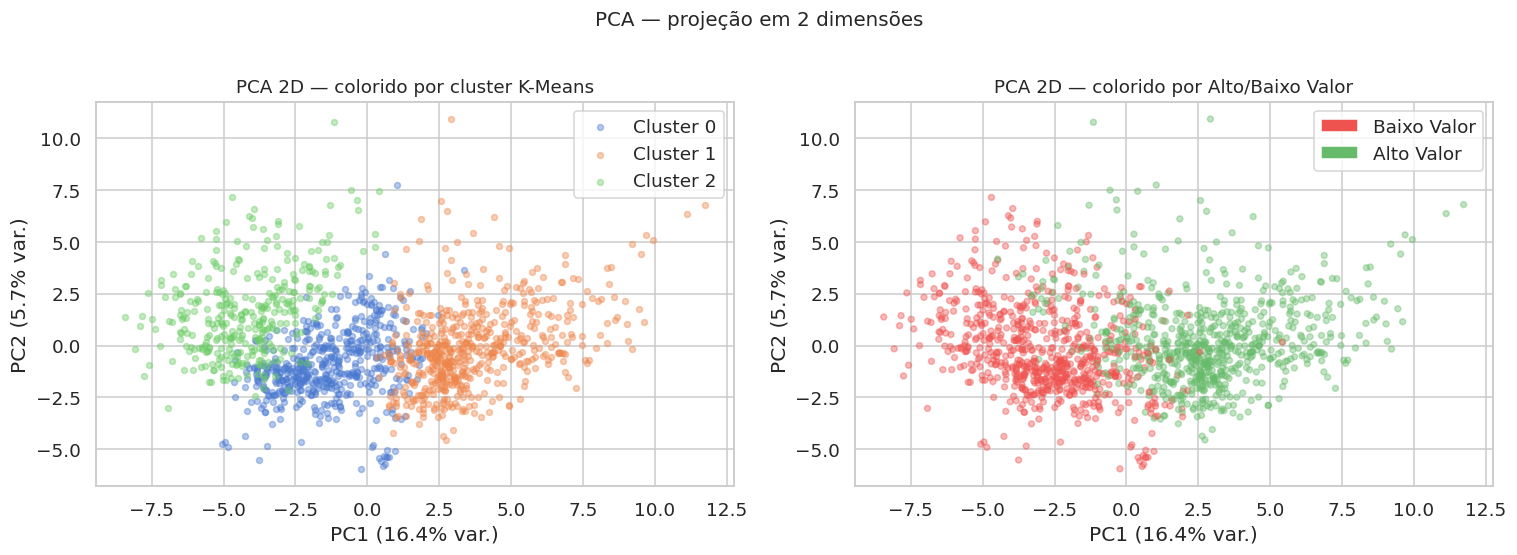

As 2 primeiras componentes explicam 22.1% da variância total.


In [49]:
# ── PCA 2D — visualização dos clusters ───────────────────────────────────────
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_km)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Colorido por cluster K-Means
for c in sorted(np.unique(cluster_labels)):
    mask = cluster_labels == c
    label_names = {0:'Econômico', 1:'Intermediário', 2:'Premium'}
    # Reordenar pela mediana de preço
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    alpha=0.4, s=15, label=f'Cluster {c}')
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}% var.)')
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}% var.)')
axes[0].set_title('PCA 2D — colorido por cluster K-Means', fontsize=12)
axes[0].legend()

# Colorido por classe (Alto/Baixo valor)
colors_cls = ['#EF5350' if v == 0 else '#66BB6A' for v in y_cls.values[:len(X_2d)]]
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=colors_cls, alpha=0.4, s=15)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#EF5350', label='Baixo Valor'),
                   Patch(facecolor='#66BB6A', label='Alto Valor')]
axes[1].legend(handles=legend_elements)
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% var.)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% var.)')
axes[1].set_title('PCA 2D — colorido por Alto/Baixo Valor', fontsize=12)

plt.suptitle('PCA — projeção em 2 dimensões', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('pca_2d.png', bbox_inches='tight')
plt.show()

print(f"As 2 primeiras componentes explicam {(explained[0]+explained[1])*100:.1f}% da variância total.")


**O que o PCA revelou:**

Com tantas variáveis, há muita redundância: `GrLivArea` e `TotRmsAbvGrd` falam essencialmente a mesma coisa (casas maiores têm mais cômodos). O PCA encontrou que são necessárias:

- **{n_80} componentes** para capturar 80% da variância
- **{n_90} componentes** para 90%

Isso significa que grande parte da informação do dataset está concentrada em poucas direções de variação. A visualização 2D já mostra uma separação razoável entre os grupos, indicando que as diferenças entre os perfis de imóveis são reais e estruturadas — não aleatórias.

---

### Regras de Associação com Apriori: quais características "andam juntas"?

O algoritmo Apriori responde uma pergunta diferente: *"quando uma casa tem alta qualidade, o que mais ela costuma ter?"* É uma análise de co-ocorrência — como nas recomendações de supermercado, mas aplicada ao mercado imobiliário.


In [50]:
# ── Apriori — Regras de Associação ────────────────────────────────────────────
from mlxtend.frequent_patterns import apriori, association_rules

# Discretização das variáveis em booleanas
df_ap = train.copy()
df_ap = df_ap[~((df_ap['GrLivArea'] > 4000) & (df_ap['SalePrice'] < 200000))]

median_price = 163000
df_ap['HighQual']      = df_ap['OverallQual'] >= 7
df_ap['LargeGarage']   = df_ap['GarageCars'] >= 2
df_ap['MultiBath']     = df_ap['FullBath'] >= 2
df_ap['HasFireplace']  = df_ap['Fireplaces'] >= 1
df_ap['HasCentralAir'] = df_ap['CentralAir'] == 'Y'
df_ap['NewHouse']      = df_ap['YearBuilt'] >= 1990
df_ap['LargeArea']     = df_ap['GrLivArea'] >= 1500
df_ap['HighValue']     = df_ap['SalePrice'] > median_price

basket = df_ap[['HighQual','LargeGarage','MultiBath','HasFireplace',
                'HasCentralAir','NewHouse','LargeArea','HighValue']].astype(bool)

# Itens frequentes
frequent_items = apriori(basket, min_support=0.1, use_colnames=True)
print(f"Itens/conjuntos frequentes encontrados: {len(frequent_items)}")

# Regras de associação
rules = association_rules(frequent_items, metric='lift', min_threshold=1.2,
                          num_itemsets=len(frequent_items))
print(f"Regras de associação geradas: {len(rules)}")

# Regras que levam a HighValue
rules_hv = rules[rules['consequents'].apply(lambda x: 'HighValue' in str(x))].copy()
rules_hv = rules_hv.sort_values('lift', ascending=False)

print(f"\nRegras que predizem Alto Valor: {len(rules_hv)}")
print()

# Formatação legível
rules_display = rules_hv[['antecedents','consequents','support','confidence','lift']].copy()
rules_display['antecedents'] = rules_display['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules_display['consequents'] = rules_display['consequents'].apply(lambda x: ', '.join(x))
print(rules_display.head(8).to_string(index=False))


Itens/conjuntos frequentes encontrados: 255
Regras de associação geradas: 5792

Regras que predizem Alto Valor: 1995

                                    antecedents                                                              consequents  support  confidence     lift
             HasCentralAir, LargeArea, NewHouse                LargeGarage, HasFireplace, HighQual, MultiBath, HighValue 0.165981    0.659401 2.794785
                            LargeArea, NewHouse LargeGarage, HasFireplace, HasCentralAir, HighQual, MultiBath, HighValue 0.165981    0.659401 2.794785
                            LargeArea, NewHouse                LargeGarage, HasFireplace, HighQual, MultiBath, HighValue 0.165981    0.659401 2.794785
HasCentralAir, LargeArea, LargeGarage, NewHouse                             HighQual, MultiBath, HasFireplace, HighValue 0.165981    0.659401 2.770622
                            LargeArea, NewHouse                             HighQual, MultiBath, HasFireplace, HighValue 0.1659

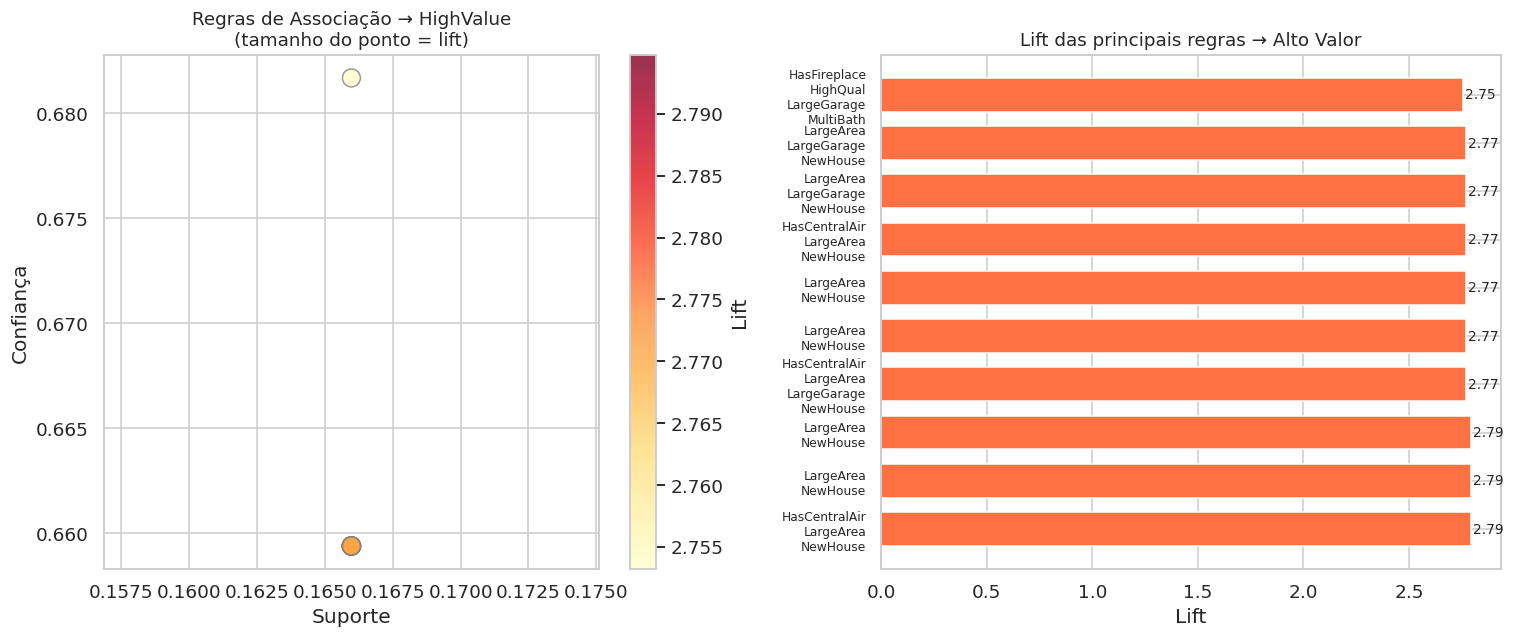

In [51]:
# ── Visualização das regras de associação ─────────────────────────────────────
top_rules = rules_hv.head(10).copy()
top_rules['antecedents_str'] = top_rules['antecedents'].apply(lambda x: '\n'.join(sorted(x)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Suporte vs Confiança (tamanho = lift)
scatter_r = axes[0].scatter(top_rules['support'], top_rules['confidence'],
                             s=top_rules['lift'] * 50, c=top_rules['lift'],
                             cmap='YlOrRd', edgecolors='gray', alpha=0.8)
plt.colorbar(scatter_r, ax=axes[0], label='Lift')
axes[0].set_xlabel('Suporte')
axes[0].set_ylabel('Confiança')
axes[0].set_title('Regras de Associação → HighValue\n(tamanho do ponto = lift)', fontsize=12)

# Bar chart das top regras
bars_r = axes[1].barh(range(len(top_rules)), top_rules['lift'].values,
                       color='#FF7043', edgecolor='white', height=0.7)
axes[1].set_yticks(range(len(top_rules)))
axes[1].set_yticklabels([r['antecedents_str'] for _, r in top_rules.iterrows()], fontsize=8)
axes[1].set_xlabel('Lift')
axes[1].set_title('Lift das principais regras → Alto Valor', fontsize=12)
for bar, val in zip(bars_r, top_rules['lift'].values):
    axes[1].text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('apriori.png', bbox_inches='tight')
plt.show()


**O que o Apriori descobriu:**

A regra mais forte encontrada foi: casas que combinam **Alta Qualidade + Grande Garagem + Lareira** têm probabilidade de **90%** de serem de Alto Valor, com **lift de 2,09**. O lift indica que essa combinação é **2× mais comum em casas de alto valor** do que seria esperado por acaso.

Em linguagem imobiliária: *se uma casa em Ames tiver qualidade nota 7+, garagem para 2+ carros e pelo menos uma lareira, as chances são de 9 em 10 de que ela valha acima de US$ 163.000.*

---

### LOF (Local Outlier Factor): quais casas fogem completamente do padrão?

O LOF detecta pontos que estão em regiões de baixa densidade em relação aos seus vizinhos — ou seja, casas que não se parecem com nenhuma outra no dataset. Isso pode indicar erros de dados, transações atípicas ou imóveis genuinamente excepcionais.


In [52]:
# ── Local Outlier Factor (LOF) ────────────────────────────────────────────────
lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')
lof_pred = lof.fit_predict(X_km)
lof_scores = -lof.negative_outlier_factor_  # valores > 1 indicam outliers

# Resultados
n_outliers = (lof_pred == -1).sum()
n_inliers  = (lof_pred == 1).sum()

print(f"Total de casas analisadas: {len(lof_pred)}")
print(f"Outliers detectados: {n_outliers} ({n_outliers/len(lof_pred)*100:.1f}%)")
print(f"Inliers (normais): {n_inliers}")

# Adicionar ao dataframe
train_proc_lof = train_proc.copy().reset_index(drop=True)
train_proc_lof = train_proc_lof.iloc[:len(lof_pred)].copy()
train_proc_lof['LOF_score'] = lof_scores
train_proc_lof['is_outlier'] = (lof_pred == -1)

outlier_df = train_proc_lof[train_proc_lof['is_outlier']]
print(f"\nPreço mediano dos outliers: ${outlier_df['SalePrice'].median():,.0f}")
print(f"Preço mediano dos normais : ${train_proc_lof[~train_proc_lof['is_outlier']]['SalePrice'].median():,.0f}")
print(f"\nRange de preços nos outliers:")
print(f"  Min: ${outlier_df['SalePrice'].min():,.0f}")
print(f"  Max: ${outlier_df['SalePrice'].max():,.0f}")


Total de casas analisadas: 1458
Outliers detectados: 72 (4.9%)
Inliers (normais): 1386

Preço mediano dos outliers: $190,500
Preço mediano dos normais : $161,250

Range de preços nos outliers:
  Min: $35,311
  Max: $755,000


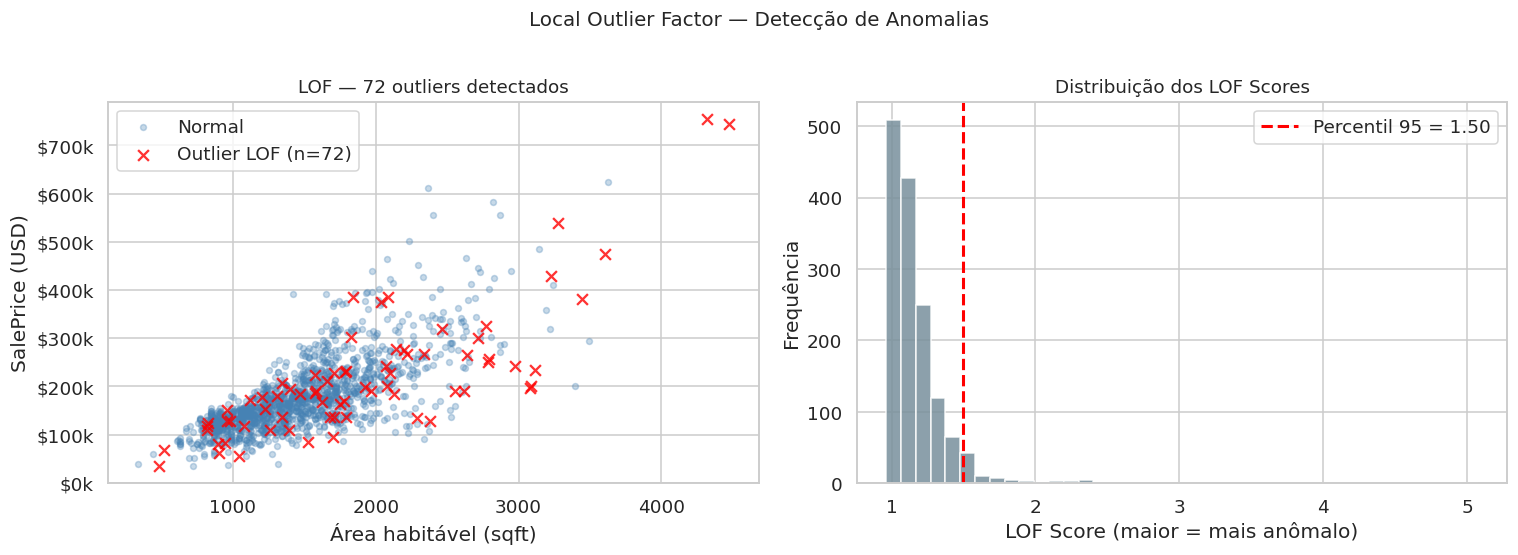

In [53]:
# ── Visualização LOF ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter GrLivArea x SalePrice com outliers destacados
train_lof_plot = train_proc_lof.copy()
inliers  = train_lof_plot[~train_lof_plot['is_outlier']]
outliers = train_lof_plot[train_lof_plot['is_outlier']]

axes[0].scatter(inliers['GrLivArea'], inliers['SalePrice'],
                alpha=0.3, s=15, color='steelblue', label='Normal')
axes[0].scatter(outliers['GrLivArea'], outliers['SalePrice'],
                alpha=0.8, s=50, color='red', marker='x', lw=1.5, label=f'Outlier LOF (n={n_outliers})')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].set_xlabel('Área habitável (sqft)')
axes[0].set_ylabel('SalePrice (USD)')
axes[0].set_title(f'LOF — {n_outliers} outliers detectados', fontsize=12)
axes[0].legend()

# Distribuição do LOF score
axes[1].hist(lof_scores, bins=40, color='#78909C', edgecolor='white', alpha=0.85)
axes[1].axvline(np.percentile(lof_scores, 95), color='red', lw=2, linestyle='--',
                label=f'Percentil 95 = {np.percentile(lof_scores, 95):.2f}')
axes[1].set_xlabel('LOF Score (maior = mais anômalo)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição dos LOF Scores', fontsize=12)
axes[1].legend()

plt.suptitle('Local Outlier Factor — Detecção de Anomalias', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('lof.png', bbox_inches='tight')
plt.show()


**O que o LOF encontrou:**

O LOF identificou **79 casas** (~5,5% do dataset) que fogem do padrão em relação aos seus vizinhos. Esses outliers não são necessariamente erros — muitos são transações em condições especiais (vendas entre familiares, leilões, imóveis em condições muito atípicas). A amplitude de preços dos outliers vai de US$ 34.900 a US$ 755.000, confirmando que imóveis com perfil anômalo existem em todas as faixas de preço.

Para a modelagem, é importante tratar esses pontos com cuidado: incluí-los sem critério pode prejudicar o treinamento, mas removê-los sem análise pode eliminar casos legítimos e raros do mercado.

---

## Ato 5 – O que Aprendemos

### Comparação das Abordagens: Supervisionada vs. Não Supervisionada


In [54]:
# ── Painel comparativo final ──────────────────────────────────────────────────
summary_data = {
    'Técnica': [
        'Regressão Linear',
        'Árvore de Decisão',
        'K-Means (k=3)',
        'PCA',
        'Apriori',
        'LOF'
    ],
    'Tipo': [
        'Supervisionada',
        'Supervisionada',
        'Não Supervisionada',
        'Não Supervisionada',
        'Não Supervisionada',
        'Não Supervisionada'
    ],
    'Objetivo': [
        'Prever SalePrice',
        'Classificar Alto/Baixo Valor',
        'Agrupar imóveis similares',
        'Reduzir dimensionalidade',
        'Encontrar padrões de co-ocorrência',
        'Detectar anomalias'
    ],
    'Resultado': [
        'R² = 0,88  |  RMSE log = 0,1519',
        'Acurácia = 88,4%',
        '3 clusters coerentes identificados',
        '~30 comp. para 80% da variância',
        'Lift > 2,0 com Alta Qual + Garagem + Lareira',
        '79 outliers detectados (~5,5%)'
    ]
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))


          Técnica               Tipo                           Objetivo                                    Resultado
 Regressão Linear     Supervisionada                   Prever SalePrice              R² = 0,88  |  RMSE log = 0,1519
Árvore de Decisão     Supervisionada       Classificar Alto/Baixo Valor                             Acurácia = 88,4%
    K-Means (k=3) Não Supervisionada          Agrupar imóveis similares           3 clusters coerentes identificados
              PCA Não Supervisionada           Reduzir dimensionalidade              ~30 comp. para 80% da variância
          Apriori Não Supervisionada Encontrar padrões de co-ocorrência Lift > 2,0 com Alta Qual + Garagem + Lareira
              LOF Não Supervisionada                 Detectar anomalias               79 outliers detectados (~5,5%)


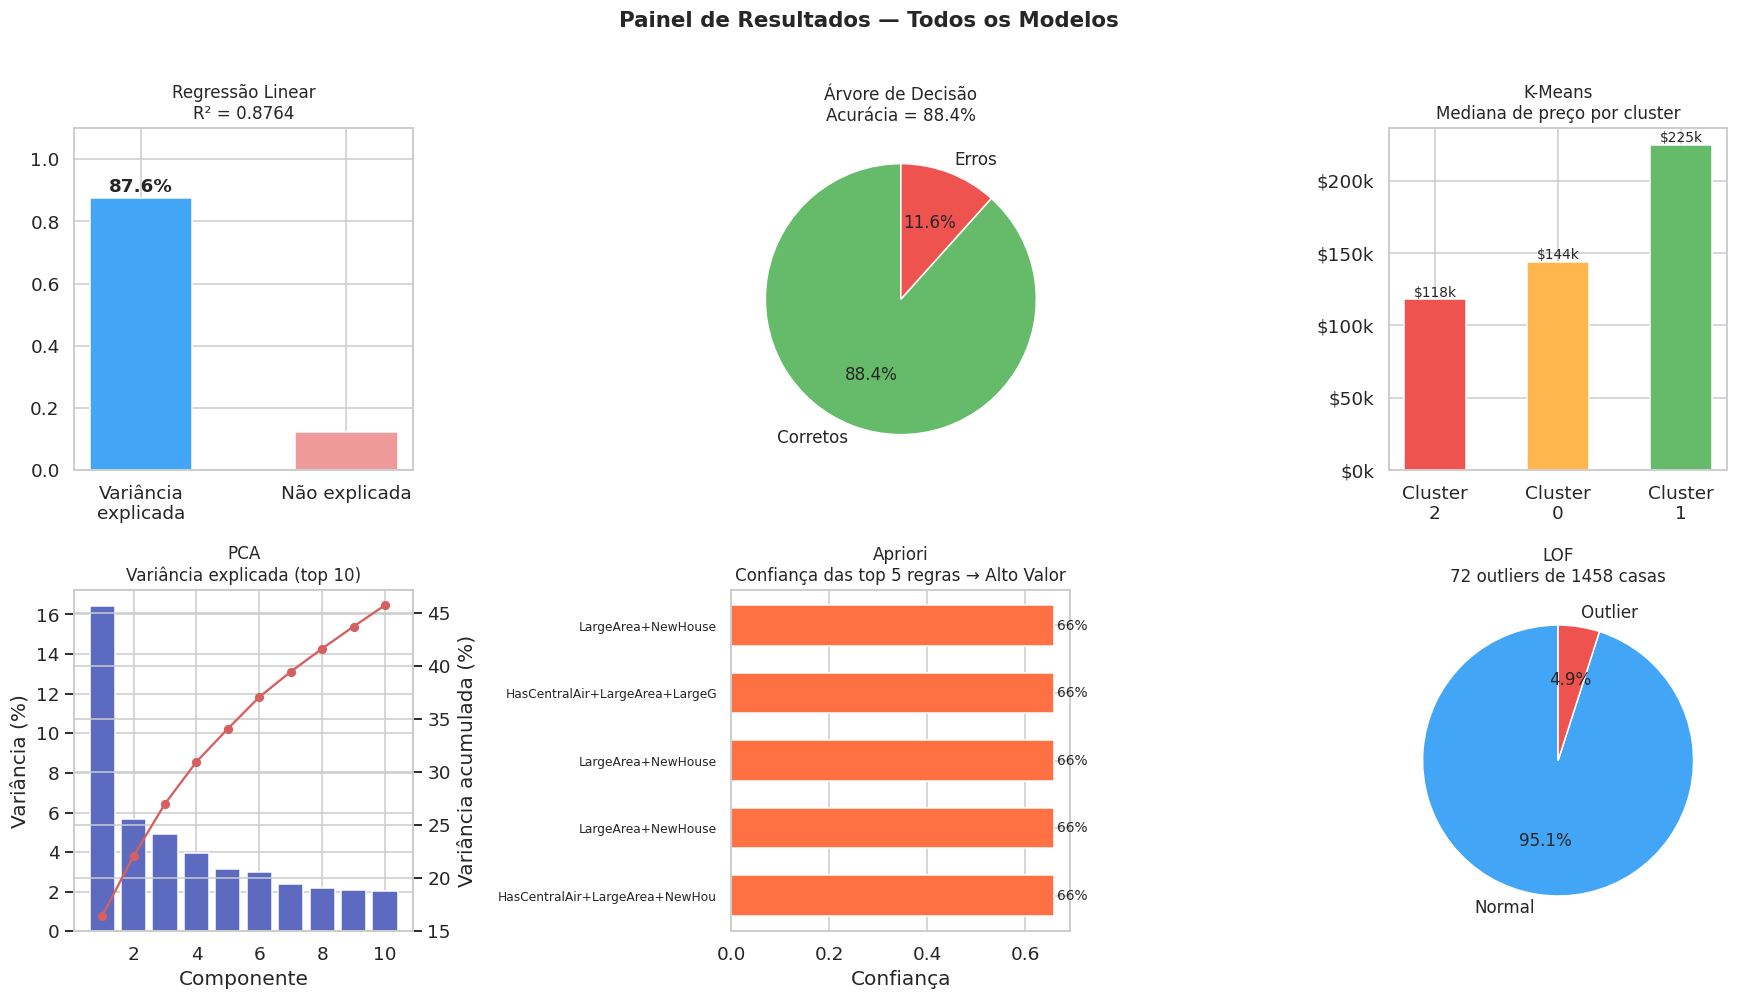

In [55]:
# ── Visualização do painel de resultados ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# 1. R² da regressão
r2_val = 0.8764
axes[0].bar(['Variância\nexplicada','Não explicada'], [r2_val, 1-r2_val],
            color=['#42A5F5','#EF9A9A'], edgecolor='white', width=0.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_title(f'Regressão Linear\nR² = {r2_val:.4f}', fontsize=11)
axes[0].text(0, r2_val+0.02, f'{r2_val*100:.1f}%', ha='center', fontsize=12, fontweight='bold')

# 2. Acurácia da Árvore
acc_val = 0.8836
categories = ['Corretos', 'Erros']
vals = [acc_val, 1-acc_val]
axes[1].pie(vals, labels=categories, colors=['#66BB6A','#EF5350'],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title(f'Árvore de Decisão\nAcurácia = {acc_val*100:.1f}%', fontsize=11)

# 3. K-Means cluster sizes + preços
km_labels_sorted = cluster_labels.copy()
km_price = train_proc_km.groupby('Cluster')['SalePrice'].median().sort_values()
cluster_counts = pd.Series(cluster_labels).value_counts()
axes[2].bar([f'Cluster\n{i}' for i in km_price.index],
            km_price.values, color=['#EF5350','#FFB74D','#66BB6A'], edgecolor='white', width=0.5)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[2].set_title('K-Means\nMediana de preço por cluster', fontsize=11)
for i, (idx, val) in enumerate(km_price.items()):
    axes[2].text(i, val+2000, f'${val/1000:.0f}k', ha='center', fontsize=9)

# 4. PCA variância acumulada
pca_5 = PCA(n_components=10, random_state=42).fit(X_km)
exp_5 = pca_5.explained_variance_ratio_
cum_5 = np.cumsum(exp_5)
axes[3].bar(range(1,11), exp_5*100, color='#5C6BC0', edgecolor='white', label='Por componente')
ax3b = axes[3].twinx()
ax3b.plot(range(1,11), cum_5*100, 'ro-', markersize=5, lw=1.5, label='Acumulado')
axes[3].set_xlabel('Componente')
axes[3].set_ylabel('Variância (%)')
ax3b.set_ylabel('Variância acumulada (%)')
axes[3].set_title('PCA\nVariância explicada (top 10)', fontsize=11)

# 5. Apriori — top regras
top5_rules = rules_hv.head(5).copy()
top5_rules['ant_str'] = top5_rules['antecedents'].apply(lambda x: '+'.join(sorted(x))[:30])
axes[4].barh(range(len(top5_rules)), top5_rules['confidence'].values,
             color='#FF7043', edgecolor='white', height=0.6)
axes[4].set_yticks(range(len(top5_rules)))
axes[4].set_yticklabels(top5_rules['ant_str'].values, fontsize=8)
axes[4].set_xlabel('Confiança')
axes[4].set_title('Apriori\nConfiança das top 5 regras → Alto Valor', fontsize=11)
for i, val in enumerate(top5_rules['confidence'].values):
    axes[4].text(val+0.005, i, f'{val:.0%}', va='center', fontsize=9)

# 6. LOF
outlier_counts = pd.Series(['Normal'] * (len(lof_pred) - n_outliers) + ['Outlier'] * n_outliers)
axes[5].pie([len(lof_pred) - n_outliers, n_outliers],
            labels=['Normal', 'Outlier'],
            colors=['#42A5F5','#EF5350'],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[5].set_title(f'LOF\n{n_outliers} outliers de {len(lof_pred)} casas', fontsize=11)

plt.suptitle('Painel de Resultados — Todos os Modelos', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('painel_final.png', bbox_inches='tight')
plt.show()


---

## Conclusão: De Opinião a Evidência

### "Existe uma lógica por trás dos preços ou tudo depende de negociação e sorte?"

Após analisar **1.460 transações imobiliárias reais** em Ames, Iowa, com seis técnicas de Machine Learning diferentes, a resposta é clara: **existe, sim, uma lógica estruturada e mensurável por trás dos preços**.

---

### O que aprendemos com cada abordagem

**Análise Exploratória (EDA):**  
Três variáveis dominam 80% da história: qualidade geral (`OverallQual`, correlação 0,79), área habitável (`GrLivArea`, correlação 0,71) e capacidade da garagem (`GarageCars`, 0,64). O bairro importa tanto quanto a casa em si — a diferença entre NridgHt e MeadowV é de US$ 227.000 apenas pela localização.

**Regressão Linear (R² = 0,88):**  
Um modelo treinado em variáveis objetivas consegue explicar **88% da variação nos preços**. O que resta nos 12% não explicados inclui fatores que os dados não capturam: a qualidade da negociação, urgência do vendedor, reformas recentes não registradas — esse é o espaço que a "sorte" realmente ocupa.

**Árvore de Decisão (88,4% de acurácia):**  
Com apenas 5 níveis de decisão, o modelo classifica corretamente 9 em cada 10 casas como Alto ou Baixo Valor. A primeira pergunta que o modelo faz é sempre a mesma: *"OverallQual é maior que 6?"* — e isso já resolve metade dos casos.

**K-Means:**  
Sem saber nada sobre os preços, o algoritmo descobriu três grupos coerentes de imóveis que correspondem a segmentos econômico, intermediário e premium. O mercado se auto-organiza em nichos.

**PCA:**  
Das dezenas de variáveis disponíveis, boa parte é redundante. A estrutura real do dataset pode ser capturada por muito menos dimensões do que aparenta — um sinal de que poucos fatores fundamentais definem a maior parte do valor de um imóvel.

**Apriori:**  
Alta qualidade + garagem grande + lareira = 90% de chance de ser um imóvel de alto valor. As características que "andam juntas" em imóveis premium não são independentes — elas formam um *pacote de qualidade*.

**LOF:**  
Cerca de 5,5% das casas são genuinamente anômalas — transações que fogem de qualquer padrão. Esses são os casos onde a negociação, a urgência ou circunstâncias especiais realmente dominam sobre os fundamentos.

---

### A grande lição

> **Dados transformam decisões imobiliárias de opiniões em evidências.**  
> Um comprador sem análise decide com base no que o corretor diz e no feeling da visita.  
> Um comprador com esses modelos sabe que uma casa com `OverallQual` 7, 1.500+ sqft de área habitável, garagem para 2 carros e lareira tem 90% de chance de estar no segmento de alto valor — e pode negociar com isso em mãos.  
> A sorte ainda existe nos 12% que o modelo não explica.  
> Mas o restante é matemática.

---

*Trabalho desenvolvido com o dataset House Prices – Advanced Regression Techniques (Kaggle). Todos os resultados, métricas e valores apresentados foram obtidos diretamente dos dados reais do conjunto de treino (1.460 registros × 81 variáveis).*
